# HIF1A SNP-informed perturbation case

This notebook contains the final reproducible workflow for the HIF1A SNP-informed case based on Replogle K562 CRISPRi data and BaiZe batch-context predictions.

The variant is used as genetic evidence pointing to HIF1A. The analysis then models reduced HIF1A activity through HIF1A CRISPRi and evaluates downstream transcriptional responses. It does not directly predict allele-specific SNP effects.

Historical BCL11A exploration, non-batch-aware prediction exports, repeated figure revisions, and unrelated demonstration code have been removed.


## 1. Candidate screening

Screen candidate perturbation genes in the Replogle K562 CRISPRi dataset using perturbation-cell counts, target-gene availability, and baseline target-gene expression.

In [1]:
# ============================================================
# SNP case candidate screening
#
#
# ============================================================

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# ------------------------------------------------------------
DATA_PATH = Path(
    "/root/autodl-fs/replogle_bcl11a/raw/"
    "ReplogleWeissman2022_K562_gwps.h5ad"
)

PERT_COL = "perturbation"
CONTROL_LABEL = "control"

N_CONTROL_SAMPLE = 2000
RANDOM_SEED = 42

CANDIDATE_TARGETS = {
    "NFE2L2": [
        "NQO1",
        "GCLC",
        "GCLM",
        "TXNRD1",
        "SLC7A11",
        "SRXN1",
        "HMOX1",
    ],

    "GATA1": [
        "HBG1",
        "HBG2",
        "HBA1",
        "HBA2",
        "AHSP",
        "ALAS2",
        "GYPA",
    ],

    "NFE2": [
        "HBG1",
        "HBG2",
        "HBA1",
        "HBA2",
        "AHSP",
        "ALAS2",
    ],

    "HIF1A": [
        "VEGFA",
        "PDK1",
        "LDHA",
        "BNIP3",
        "SLC2A1",
        "CA9",
    ],

    "ATF4": [
        "ASNS",
        "DDIT3",
        "TRIB3",
        "CHAC1",
        "SLC7A11",
        "ATF3",
    ],

    "DDIT3": [
        "TRIB3",
        "CHAC1",
        "ATF3",
        "ASNS",
        "GADD34",
        "PPP1R15A",
    ],

    "MYC": [
        "NCL",
        "NPM1",
        "ODC1",
        "LDHA",
        "ENO1",
        "HK2",
    ],
}

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# ------------------------------------------------------------
adata = ad.read_h5ad(
    DATA_PATH,
    backed="r",
)

print("=" * 100)
print('Dataset summary')
print("=" * 100)

print("Path :", DATA_PATH)
print("Shape:", adata.shape)
print("X type:", type(adata.X))


# ------------------------------------------------------------
# ------------------------------------------------------------
perturbation_values = (
    adata.obs[PERT_COL]
    .astype(str)
)

perturbation_counts = (
    perturbation_values
    .value_counts()
)

print("\nControl cells:", int(
    perturbation_counts.get(
        CONTROL_LABEL,
        0,
    )
))


# ------------------------------------------------------------
# ------------------------------------------------------------
var_names = pd.Index(
    adata.var_names.astype(str)
)

var_upper = pd.Index(
    var_names.str.upper()
)

gene_to_index = {}

for idx, gene in enumerate(var_upper):
    if gene not in gene_to_index:
        gene_to_index[gene] = idx


# ------------------------------------------------------------
# ------------------------------------------------------------
all_target_genes = sorted({
    gene
    for targets in CANDIDATE_TARGETS.values()
    for gene in targets
})

present_target_genes = [
    gene
    for gene in all_target_genes
    if gene.upper() in gene_to_index
]

missing_target_genes = [
    gene
    for gene in all_target_genes
    if gene.upper() not in gene_to_index
]

print("\nPresent target genes:")
print(present_target_genes)

print("\nMissing target genes:")
print(missing_target_genes)


# ------------------------------------------------------------
# ------------------------------------------------------------
control_rows_all = np.flatnonzero(
    perturbation_values.to_numpy()
    == CONTROL_LABEL
)

n_control_sample = min(
    N_CONTROL_SAMPLE,
    len(control_rows_all),
)

control_rows = np.sort(
    rng.choice(
        control_rows_all,
        size=n_control_sample,
        replace=False,
    )
)

print(
    "\nSampled control cells:",
    len(control_rows),
)


# ------------------------------------------------------------
#
# ------------------------------------------------------------
X_control_rows = adata.X[
    control_rows,
    :
]

if sparse.issparse(X_control_rows):
    X_control_rows = X_control_rows.toarray()
else:
    X_control_rows = np.asarray(
        X_control_rows
    )

target_indices = [
    gene_to_index[gene.upper()]
    for gene in present_target_genes
]

X_control_targets = X_control_rows[
    :,
    target_indices
].astype(np.float64)

del X_control_rows
gc.collect()


# ------------------------------------------------------------
# ------------------------------------------------------------
control_expression_rows = []

for j, gene in enumerate(
    present_target_genes
):

    values = X_control_targets[:, j]

    control_expression_rows.append({
        "gene": gene,
        "control_mean_count": float(
            np.mean(values)
        ),
        "control_median_count": float(
            np.median(values)
        ),
        "control_pct_nonzero": float(
            np.mean(values > 0) * 100
        ),
        "control_max_count": float(
            np.max(values)
        ),
    })

control_expression_df = pd.DataFrame(
    control_expression_rows
)

print("\n" + "=" * 100)
print('Baseline expression of candidate downstream genes in control cells')
print("=" * 100)

display(
    control_expression_df.sort_values(
        "control_pct_nonzero",
        ascending=False,
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# ------------------------------------------------------------
candidate_rows = []
candidate_target_rows = []

for candidate, targets in (
    CANDIDATE_TARGETS.items()
):

    n_perturb_cells = int(
        perturbation_counts.get(
            candidate,
            0,
        )
    )

    candidate_in_expression = (
        candidate.upper()
        in gene_to_index
    )

    available_targets = [
        gene
        for gene in targets
        if gene.upper() in gene_to_index
    ]

    missing_targets = [
        gene
        for gene in targets
        if gene.upper() not in gene_to_index
    ]

    current_stats = (
        control_expression_df
        .loc[
            control_expression_df[
                "gene"
            ].isin(available_targets)
        ]
        .copy()
    )

    if len(current_stats) > 0:
        median_pct_nonzero = float(
            current_stats[
                "control_pct_nonzero"
            ].median()
        )

        n_detected_5pct = int(
            (
                current_stats[
                    "control_pct_nonzero"
                ]
                >= 5
            ).sum()
        )

        n_detected_20pct = int(
            (
                current_stats[
                    "control_pct_nonzero"
                ]
                >= 20
            ).sum()
        )
    else:
        median_pct_nonzero = np.nan
        n_detected_5pct = 0
        n_detected_20pct = 0

    candidate_rows.append({
        "candidate": candidate,
        "n_perturb_cells": n_perturb_cells,
        "candidate_gene_in_matrix":
            candidate_in_expression,
        "n_expected_targets": len(targets),
        "n_targets_present":
            len(available_targets),
        "n_targets_control_detected_ge5pct":
            n_detected_5pct,
        "n_targets_control_detected_ge20pct":
            n_detected_20pct,
        "median_control_pct_nonzero":
            median_pct_nonzero,
        "available_targets":
            " | ".join(available_targets),
        "missing_targets":
            " | ".join(missing_targets),
    })

    for gene in targets:

        row = {
            "candidate": candidate,
            "target_gene": gene,
            "present": (
                gene.upper()
                in gene_to_index
            ),
        }

        gene_stats = (
            control_expression_df
            .loc[
                control_expression_df[
                    "gene"
                ] == gene
            ]
        )

        if len(gene_stats) > 0:
            row.update({
                "control_mean_count":
                    float(
                        gene_stats.iloc[0][
                            "control_mean_count"
                        ]
                    ),
                "control_pct_nonzero":
                    float(
                        gene_stats.iloc[0][
                            "control_pct_nonzero"
                        ]
                    ),
            })
        else:
            row.update({
                "control_mean_count":
                    np.nan,
                "control_pct_nonzero":
                    np.nan,
            })

        candidate_target_rows.append(row)


candidate_summary_df = pd.DataFrame(
    candidate_rows
)

candidate_target_df = pd.DataFrame(
    candidate_target_rows
)


# ------------------------------------------------------------
#
# ------------------------------------------------------------
candidate_summary_df[
    "screening_score"
] = (
    np.log1p(
        candidate_summary_df[
            "n_perturb_cells"
        ]
    )
    + candidate_summary_df[
        "n_targets_control_detected_ge5pct"
    ]
    + 0.5 * candidate_summary_df[
        "n_targets_control_detected_ge20pct"
    ]
)

candidate_summary_df = (
    candidate_summary_df
    .sort_values(
        [
            "screening_score",
            "n_perturb_cells",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print('Candidate perturbation ranking')
print("=" * 100)

display(candidate_summary_df)


print("\n" + "=" * 100)
print('Target-gene details for each candidate')
print("=" * 100)

display(candidate_target_df)


# ------------------------------------------------------------
# ------------------------------------------------------------
usable = candidate_summary_df.loc[
    (
        candidate_summary_df[
            "n_perturb_cells"
        ] >= 100
    )
    & (
        candidate_summary_df[
            "n_targets_control_detected_ge5pct"
        ] >= 3
    )
].copy()

print("\n" + "=" * 100)
print('Preliminarily eligible candidates')
print("=" * 100)

if len(usable) > 0:
    display(usable)

    best_candidate = str(
        usable.iloc[0]["candidate"]
    )

    print(
        '\nAutomatically selected leading candidate:',
        best_candidate,
    )
else:
    print(
        'No candidate currently satisfies:'
        'at least 100 perturbed cells and at least three detectable target genes.'
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
try:
    adata.file.close()
except Exception:
    pass

del adata
gc.collect()

print(
    '\nScreening completed. Review the candidate perturbation ranking and'
    'the preliminarily eligible candidate table.'
)



libgomp: Invalid value for environment variable OMP_NUM_THREADS


Dataset summary
Path : /root/autodl-fs/replogle_bcl11a/raw/ReplogleWeissman2022_K562_gwps.h5ad
Shape: (1989578, 8248)
X type: <class 'h5py._hl.dataset.Dataset'>

Control cells: 75328

Present target genes:
['ALAS2', 'ATF3', 'BNIP3', 'DDIT3', 'ENO1', 'GCLC', 'GCLM', 'GYPA', 'HBA1', 'HBG1', 'HBG2', 'HK2', 'LDHA', 'NCL', 'NPM1', 'NQO1', 'ODC1', 'PDK1', 'PPP1R15A', 'SLC2A1', 'SLC7A11', 'TRIB3', 'TXNRD1', 'VEGFA']

Missing target genes:
['AHSP', 'ASNS', 'CA9', 'CHAC1', 'GADD34', 'HBA2', 'HMOX1', 'SRXN1']

Sampled control cells: 2000

Baseline expression of candidate downstream genes in control cells


,gene,control_mean_count,control_median_count,control_pct_nonzero,control_max_count
0,NPM1,40.3475,38.0,99.75,371.0
1,NCL,19.7860,18.0,99.55,78.0
2,ENO1,15.1070,14.0,99.45,80.0
3,LDHA,7.0070,6.0,97.15,39.0
4,ODC1,3.8950,3.0,90.45,22.0
5,HBG2,9.6720,4.0,78.05,230.0
6,GYPA,1.7825,1.0,72.70,23.0
7,TXNRD1,1.3845,1.0,68.85,11.0
8,HBG1,3.6015,1.0,61.60,66.0
9,PPP1R15A,0.7570,0.0,46.35,11.0



Candidate perturbation ranking


,candidate,n_perturb_cells,candidate_gene_in_matrix,n_expected_targets,n_targets_present,n_targets_control_detected_ge5pct,n_targets_control_detected_ge20pct,median_control_pct_nonzero,available_targets,missing_targets,screening_score
0,MYC,99,True,6,6,6,5,98.30,NCL | NPM1 | ODC1 | LDHA | ENO1 | HK2,,13.105170
1,NFE2L2,140,True,7,5,5,4,35.10,NQO1 | GCLC | GCLM | TXNRD1 | SLC7A11,SRXN1 | HMOX1,11.948760
2,HIF1A,163,True,6,5,5,3,36.15,VEGFA | PDK1 | LDHA | BNIP3 | SLC2A1,CA9,11.599866
3,GATA1,46,True,7,5,5,4,61.60,HBG1 | HBG2 | HBA1 | ALAS2 | GYPA,HBA2 | AHSP,10.850148
4,NFE2,145,True,6,4,4,3,43.05,HBG1 | HBG2 | HBA1 | ALAS2,HBA2 | AHSP,10.483607
5,ATF4,103,True,6,4,4,3,22.10,DDIT3 | TRIB3 | SLC7A11 | ATF3,ASNS | CHAC1,10.144391
6,DDIT3,264,True,6,3,3,2,39.30,TRIB3 | ATF3 | PPP1R15A,CHAC1 | ASNS | GADD34,9.579730



Target-gene details for each candidate


,candidate,target_gene,present,control_mean_count,control_pct_nonzero
0,NFE2L2,NQO1,True,0.4675,35.10
1,NFE2L2,GCLC,True,0.2160,18.95
2,NFE2L2,GCLM,True,0.5645,40.35
3,NFE2L2,TXNRD1,True,1.3845,68.85
4,NFE2L2,SLC7A11,True,0.2585,20.05
5,NFE2L2,SRXN1,False,NaN,NaN
6,NFE2L2,HMOX1,False,NaN,NaN
7,GATA1,HBG1,True,3.6015,61.60
8,GATA1,HBG2,True,9.6720,78.05
9,GATA1,HBA1,True,0.3645,24.50



Preliminarily eligible candidates


,candidate,n_perturb_cells,candidate_gene_in_matrix,n_expected_targets,n_targets_present,n_targets_control_detected_ge5pct,n_targets_control_detected_ge20pct,median_control_pct_nonzero,available_targets,missing_targets,screening_score
1,NFE2L2,140,True,7,5,5,4,35.10,NQO1 | GCLC | GCLM | TXNRD1 | SLC7A11,SRXN1 | HMOX1,11.948760
2,HIF1A,163,True,6,5,5,3,36.15,VEGFA | PDK1 | LDHA | BNIP3 | SLC2A1,CA9,11.599866
4,NFE2,145,True,6,4,4,3,43.05,HBG1 | HBG2 | HBA1 | ALAS2,HBA2 | AHSP,10.483607
5,ATF4,103,True,6,4,4,3,22.10,DDIT3 | TRIB3 | SLC7A11 | ATF3,ASNS | CHAC1,10.144391
6,DDIT3,264,True,6,3,3,2,39.30,TRIB3 | ATF3 | PPP1R15A,CHAC1 | ASNS | GADD34,9.579730



Automatically selected leading candidate: NFE2L2

Screening completed. Review the candidate perturbation ranking andthe preliminarily eligible candidate table.


## 2. Candidate direction validation

Validate candidate perturbations against batch-matched controls and rank them by perturbation-gene suppression and expected downstream response direction.

In [2]:
# ============================================================
# Human SNP case - candidate direction validation
#
#
# ============================================================

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
from scipy.stats import mannwhitneyu
from IPython.display import display

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# ------------------------------------------------------------
DATA_PATH = Path(
    "/root/autodl-fs/replogle_bcl11a/raw/"
    "ReplogleWeissman2022_K562_gwps.h5ad"
)

OUT_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "snp_candidate_direction_screen"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PERT_COL = "perturbation"
CONTROL_LABEL = "control"
BATCH_COL = "batch"

CONTROL_RATIO = 5
RANDOM_SEED = 42

CANDIDATE_TARGETS = {
    "NFE2L2": [
        "NQO1",
        "GCLC",
        "GCLM",
        "TXNRD1",
        "SLC7A11",
    ],

    "HIF1A": [
        "VEGFA",
        "PDK1",
        "LDHA",
        "BNIP3",
        "SLC2A1",
    ],

    "NFE2": [
        "HBG1",
        "HBG2",
        "HBA1",
        "ALAS2",
    ],

    "ATF4": [
        "DDIT3",
        "TRIB3",
        "SLC7A11",
        "ATF3",
    ],

    "DDIT3": [
        "TRIB3",
        "ATF3",
        "PPP1R15A",
    ],

    "MYC": [
        "NCL",
        "NPM1",
        "ODC1",
        "LDHA",
        "ENO1",
        "HK2",
    ],
}

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# 1. BH-FDR
# ------------------------------------------------------------
def benjamini_hochberg(p_values):
    '\n    Apply the Benjamini-Hochberg false-discovery-rate correction.\n    '
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted = np.full(
        len(p_values),
        np.nan,
        dtype=float,
    )

    valid = np.isfinite(p_values)

    if valid.sum() == 0:
        return adjusted

    p = p_values[valid]
    order = np.argsort(p)

    ranked_p = p[order]
    n = len(ranked_p)

    ranked_q = (
        ranked_p
        * n
        / np.arange(1, n + 1)
    )

    ranked_q = np.minimum.accumulate(
        ranked_q[::-1]
    )[::-1]

    ranked_q = np.minimum(
        ranked_q,
        1.0,
    )

    q = np.empty_like(ranked_q)
    q[order] = ranked_q

    adjusted[valid] = q

    return adjusted


# ------------------------------------------------------------
# ------------------------------------------------------------
adata = ad.read_h5ad(
    DATA_PATH,
    backed="r",
)

print("=" * 100)
print('Dataset summary')
print("=" * 100)

print("Path :", DATA_PATH)
print("Shape:", adata.shape)
print("X type:", type(adata.X))

assert PERT_COL in adata.obs.columns
assert BATCH_COL in adata.obs.columns


# ------------------------------------------------------------
# ------------------------------------------------------------
pert_values = (
    adata.obs[PERT_COL]
    .astype(str)
    .to_numpy()
)

batch_values = (
    adata.obs[BATCH_COL]
    .to_numpy()
)

control_rows_all = np.flatnonzero(
    pert_values == CONTROL_LABEL
)

print("Control cells:", len(control_rows_all))

var_names = pd.Index(
    adata.var_names.astype(str)
)

gene_to_index = {}

for idx, gene in enumerate(
    var_names.str.upper()
):
    if gene not in gene_to_index:
        gene_to_index[gene] = idx


# ------------------------------------------------------------
# ------------------------------------------------------------
def match_controls_by_batch(
    perturb_rows,
    candidate_seed,
):
    '\n    Randomly select batch-matched control cells using the configured control ratio.\n    '
    local_rng = np.random.default_rng(
        candidate_seed
    )

    perturb_rows = np.sort(
        np.asarray(
            perturb_rows,
            dtype=int,
        )
    )

    perturb_batches = batch_values[
        perturb_rows
    ]

    selected_controls = []
    matching_rows = []

    for batch_id in pd.unique(
        perturb_batches
    ):

        perturb_in_batch = perturb_rows[
            perturb_batches == batch_id
        ]

        controls_in_batch = control_rows_all[
            batch_values[
                control_rows_all
            ] == batch_id
        ]

        requested_n = min(
            len(controls_in_batch),
            len(perturb_in_batch)
            * CONTROL_RATIO,
        )

        if requested_n > 0:
            selected = local_rng.choice(
                controls_in_batch,
                size=requested_n,
                replace=False,
            )

            selected_controls.extend(
                selected.tolist()
            )

        matching_rows.append({
            "batch": batch_id,
            "n_perturb": len(
                perturb_in_batch
            ),
            "available_controls": len(
                controls_in_batch
            ),
            "selected_controls":
                requested_n,
        })

    selected_controls = np.asarray(
        sorted(
            set(selected_controls)
        ),
        dtype=int,
    )

    return (
        selected_controls,
        pd.DataFrame(matching_rows),
    )


# ------------------------------------------------------------
#
# ------------------------------------------------------------
def read_selected_expression(
    row_indices,
    selected_genes,
):
    row_indices = np.sort(
        np.asarray(
            row_indices,
            dtype=int,
        )
    )

    X_rows = adata.X[
        row_indices,
        :
    ]

    if sparse.issparse(X_rows):
        X_rows = X_rows.toarray()
    else:
        X_rows = np.asarray(
            X_rows
        )

    column_indices = [
        gene_to_index[
            gene.upper()
        ]
        for gene in selected_genes
    ]

    X_selected = X_rows[
        :,
        column_indices
    ].astype(np.float64)

    del X_rows
    gc.collect()

    return (
        row_indices,
        X_selected,
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
def get_library_size(
    row_indices,
):
    if "ncounts" in adata.obs.columns:
        library = pd.to_numeric(
            adata.obs.iloc[
                row_indices
            ]["ncounts"],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

        source = "ncounts"

    elif "UMI_count" in adata.obs.columns:
        library = pd.to_numeric(
            adata.obs.iloc[
                row_indices
            ]["UMI_count"],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

        source = "UMI_count"

    else:
        raise KeyError(
            'Neither ncounts nor UMI_count was found.'
        )

    library = np.where(
        library > 0,
        library,
        np.nan,
    )

    return library, source


# ------------------------------------------------------------
# ------------------------------------------------------------
all_detail_rows = []
all_matching_rows = []
candidate_summary_rows = []

for candidate_index, (
    candidate,
    target_genes,
) in enumerate(
    CANDIDATE_TARGETS.items()
):

    print("\n" + "#" * 100)
    print("Candidate:", candidate)
    print("#" * 100)

    perturb_rows = np.flatnonzero(
        pert_values == candidate
    )

    print(
        "Perturbation cells:",
        len(perturb_rows),
    )

    if len(perturb_rows) == 0:
        print('Skipped because no perturbed cells were found.')
        continue

    selected_genes = [
        candidate
    ] + [
        gene
        for gene in target_genes
        if gene != candidate
    ]

    selected_genes = [
        gene
        for gene in selected_genes
        if gene.upper()
        in gene_to_index
    ]

    print(
        "Selected genes:",
        selected_genes,
    )

    matched_control_rows, matching_df = (
        match_controls_by_batch(
            perturb_rows=perturb_rows,
            candidate_seed=(
                RANDOM_SEED
                + candidate_index
                * 100
            ),
        )
    )

    print(
        "Matched controls:",
        len(matched_control_rows),
    )

    matching_df.insert(
        0,
        "candidate",
        candidate,
    )

    all_matching_rows.append(
        matching_df
    )

    perturb_rows_sorted, X_pert = (
        read_selected_expression(
            row_indices=perturb_rows,
            selected_genes=selected_genes,
        )
    )

    control_rows_sorted, X_ctrl = (
        read_selected_expression(
            row_indices=matched_control_rows,
            selected_genes=selected_genes,
        )
    )

    # library size
    lib_pert, library_source = (
        get_library_size(
            perturb_rows_sorted
        )
    )

    lib_ctrl, _ = get_library_size(
        control_rows_sorted
    )

    X_pert_norm = np.log1p(
        X_pert
        / lib_pert[:, None]
        * 1e4
    )

    X_ctrl_norm = np.log1p(
        X_ctrl
        / lib_ctrl[:, None]
        * 1e4
    )

    perturb_batches = batch_values[
        perturb_rows_sorted
    ]

    control_batches = batch_values[
        control_rows_sorted
    ]

    candidate_detail_rows = []

    for gene_index, gene in enumerate(
        selected_genes
    ):

        pert_raw = X_pert[
            :,
            gene_index
        ]

        ctrl_raw = X_ctrl[
            :,
            gene_index
        ]

        pert_norm = X_pert_norm[
            :,
            gene_index
        ]

        ctrl_norm = X_ctrl_norm[
            :,
            gene_index
        ]

        # pseudobulk CPM
        pert_cpm = (
            np.sum(pert_raw)
            / np.nansum(lib_pert)
            * 1e6
        )

        ctrl_cpm = (
            np.sum(ctrl_raw)
            / np.nansum(lib_ctrl)
            * 1e6
        )

        pseudobulk_log2fc = np.log2(
            (pert_cpm + 0.1)
            / (ctrl_cpm + 0.1)
        )

        try:
            _, mw_p = mannwhitneyu(
                pert_norm,
                ctrl_norm,
                alternative="two-sided",
            )
        except Exception:
            mw_p = np.nan

        batch_differences = []

        for batch_id in pd.unique(
            perturb_batches
        ):

            pert_mask = (
                perturb_batches
                == batch_id
            )

            ctrl_mask = (
                control_batches
                == batch_id
            )

            if (
                pert_mask.sum() == 0
                or ctrl_mask.sum() == 0
            ):
                continue

            batch_difference = (
                np.nanmean(
                    pert_norm[
                        pert_mask
                    ]
                )
                - np.nanmean(
                    ctrl_norm[
                        ctrl_mask
                    ]
                )
            )

            batch_differences.append(
                batch_difference
            )

        if len(batch_differences) > 0:
            batch_differences = np.asarray(
                batch_differences,
                dtype=float,
            )

            batch_down_fraction = float(
                np.mean(
                    batch_differences < 0
                )
            )

            median_batch_difference = float(
                np.median(
                    batch_differences
                )
            )
        else:
            batch_down_fraction = np.nan
            median_batch_difference = np.nan

        role = (
            "self"
            if gene == candidate
            else "target"
        )

        row = {
            "candidate": candidate,
            "gene": gene,
            "role": role,

            "n_perturb_cells":
                len(pert_raw),
            "n_control_cells":
                len(ctrl_raw),

            "perturb_mean_count":
                float(
                    np.mean(
                        pert_raw
                    )
                ),
            "control_mean_count":
                float(
                    np.mean(
                        ctrl_raw
                    )
                ),

            "perturb_pct_nonzero":
                float(
                    np.mean(
                        pert_raw > 0
                    )
                    * 100
                ),
            "control_pct_nonzero":
                float(
                    np.mean(
                        ctrl_raw > 0
                    )
                    * 100
                ),

            "perturb_pseudobulk_CPM":
                float(pert_cpm),
            "control_pseudobulk_CPM":
                float(ctrl_cpm),

            "pseudobulk_log2FC":
                float(
                    pseudobulk_log2fc
                ),

            "mean_log1p_difference":
                float(
                    np.nanmean(
                        pert_norm
                    )
                    - np.nanmean(
                        ctrl_norm
                    )
                ),

            "MannWhitney_p":
                float(mw_p),

            "batch_down_fraction":
                batch_down_fraction,

            "median_batch_difference":
                median_batch_difference,
        }

        candidate_detail_rows.append(
            row
        )

    candidate_detail_df = pd.DataFrame(
        candidate_detail_rows
    )

    candidate_detail_df[
        "MannWhitney_FDR"
    ] = benjamini_hochberg(
        candidate_detail_df[
            "MannWhitney_p"
        ].to_numpy()
    )

    all_detail_rows.extend(
        candidate_detail_df
        .to_dict("records")
    )

    print("\nGene-level results:")
    display(candidate_detail_df)

    # --------------------------------------------------------
    # --------------------------------------------------------
    self_row = (
        candidate_detail_df
        .loc[
            candidate_detail_df[
                "role"
            ] == "self"
        ]
    )

    target_df = (
        candidate_detail_df
        .loc[
            candidate_detail_df[
                "role"
            ] == "target"
        ]
        .copy()
    )

    if len(self_row) > 0:
        self_log2fc = float(
            self_row.iloc[0][
                "pseudobulk_log2FC"
            ]
        )

        self_fdr = float(
            self_row.iloc[0][
                "MannWhitney_FDR"
            ]
        )

        self_down = (
            self_log2fc < 0
        )
    else:
        self_log2fc = np.nan
        self_fdr = np.nan
        self_down = False

    n_targets = len(target_df)

    n_targets_down = int(
        (
            target_df[
                "pseudobulk_log2FC"
            ] < 0
        ).sum()
    )

    direction_concordance = (
        n_targets_down / n_targets
        if n_targets > 0
        else np.nan
    )

    median_target_log2fc = (
        float(
            target_df[
                "pseudobulk_log2FC"
            ].median()
        )
        if n_targets > 0
        else np.nan
    )

    mean_target_log2fc = (
        float(
            target_df[
                "pseudobulk_log2FC"
            ].mean()
        )
        if n_targets > 0
        else np.nan
    )

    n_targets_down_fdr05 = int(
        (
            (
                target_df[
                    "pseudobulk_log2FC"
                ] < 0
            )
            & (
                target_df[
                    "MannWhitney_FDR"
                ] < 0.05
            )
        ).sum()
    )

    mean_batch_down_fraction = (
        float(
            target_df[
                "batch_down_fraction"
            ].mean()
        )
        if n_targets > 0
        else np.nan
    )

    candidate_summary_rows.append({
        "candidate": candidate,

        "n_perturb_cells":
            len(perturb_rows_sorted),
        "n_matched_controls":
            len(control_rows_sorted),
        "n_batches":
            len(
                pd.unique(
                    perturb_batches
                )
            ),

        "self_log2FC":
            self_log2fc,
        "self_FDR":
            self_fdr,
        "self_down":
            self_down,

        "n_targets":
            n_targets,
        "n_targets_down":
            n_targets_down,
        "direction_concordance":
            direction_concordance,

        "median_target_log2FC":
            median_target_log2fc,
        "mean_target_log2FC":
            mean_target_log2fc,

        "n_targets_down_FDR05":
            n_targets_down_fdr05,

        "mean_batch_down_fraction":
            mean_batch_down_fraction,

        "targets": " | ".join(
            target_df[
                "gene"
            ].tolist()
        ),
    })

    del (
        X_pert,
        X_ctrl,
        X_pert_norm,
        X_ctrl_norm,
    )

    gc.collect()


# ------------------------------------------------------------
# ------------------------------------------------------------
detail_df = pd.DataFrame(
    all_detail_rows
)

summary_df = pd.DataFrame(
    candidate_summary_rows
)

matching_all_df = pd.concat(
    all_matching_rows,
    ignore_index=True,
)


# ------------------------------------------------------------
#
# ------------------------------------------------------------
summary_df = (
    summary_df
    .sort_values(
        [
            "self_down",
            "direction_concordance",
            "n_targets_down_FDR05",
            "median_target_log2FC",
            "n_perturb_cells",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


print("\n\n" + "=" * 110)
print('Candidate direction-validation summary')
print("=" * 110)

display(summary_df)


print("\n" + "=" * 110)
print('All gene-level results')
print("=" * 110)

display(
    detail_df.sort_values(
        [
            "candidate",
            "role",
            "pseudobulk_log2FC",
        ]
    ).reset_index(drop=True)
)


# ------------------------------------------------------------
# ------------------------------------------------------------
strict_candidates = summary_df.loc[
    (
        summary_df[
            "self_down"
        ]
    )
    & (
        summary_df[
            "direction_concordance"
        ] >= 0.6
    )
    & (
        summary_df[
            "median_target_log2FC"
        ] < 0
    )
].copy()

print("\n" + "=" * 110)
print('Candidates satisfying the basic direction criteria')
print("=" * 110)

if len(strict_candidates) > 0:
    display(strict_candidates)

    best_candidate = str(
        strict_candidates.iloc[0][
            "candidate"
        ]
    )

    print(
        '\nCurrent leading candidate:',
        best_candidate,
    )

else:
    print(
        'No candidate simultaneously satisfies:'
        'decreased expression of the perturbed gene, at least 60% of downstream genes decreased, and'
        'a downstream median log2 fold change below zero.'
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
summary_path = (
    OUT_DIR
    / "candidate_direction_validation_summary.csv"
)

detail_path = (
    OUT_DIR
    / "candidate_direction_validation_gene_details.csv"
)

matching_path = (
    OUT_DIR
    / "candidate_direction_validation_matching.csv"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

detail_df.to_csv(
    detail_path,
    index=False,
)

matching_all_df.to_csv(
    matching_path,
    index=False,
)

print("\nSaved:")
print(summary_path)
print(detail_path)
print(matching_path)


# ------------------------------------------------------------
# ------------------------------------------------------------
try:
    adata.file.close()
except Exception:
    pass

del adata
gc.collect()


Dataset summary
Path : /root/autodl-fs/replogle_bcl11a/raw/ReplogleWeissman2022_K562_gwps.h5ad
Shape: (1989578, 8248)
X type: <class 'h5py._hl.dataset.Dataset'>
Control cells: 75328

####################################################################################################
Candidate: NFE2L2
####################################################################################################
Perturbation cells: 140
Selected genes: ['NFE2L2', 'NQO1', 'GCLC', 'GCLM', 'TXNRD1', 'SLC7A11']
Matched controls: 700

Gene-level results:


,candidate,gene,role,n_perturb_cells,n_control_cells,perturb_mean_count,control_mean_count,perturb_pct_nonzero,control_pct_nonzero,perturb_pseudobulk_CPM,control_pseudobulk_CPM,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_p,batch_down_fraction,median_batch_difference,MannWhitney_FDR
0,NFE2L2,NFE2L2,self,140,700,0.528571,1.007143,35.000000,58.000000,41.818352,83.958657,-1.003814,-0.245253,2.588156e-08,0.759259,-0.331520,1.552894e-07
1,NFE2L2,NQO1,target,140,700,0.457143,0.481429,31.428571,35.428571,36.167224,40.133429,-0.149728,-0.042841,3.082444e-01,0.592593,-0.139102,4.623666e-01
2,NFE2L2,GCLC,target,140,700,0.250000,0.202857,23.571429,17.714286,19.778950,16.910822,0.224789,0.020914,1.456788e-01,0.500000,-0.017189,4.370365e-01
3,NFE2L2,GCLM,target,140,700,0.578571,0.551429,39.285714,39.857143,45.774142,45.968853,-0.006110,-0.006596,8.262629e-01,0.555556,-0.100060,9.915155e-01
4,NFE2L2,TXNRD1,target,140,700,1.392857,1.422857,71.428571,70.000000,110.197010,118.613932,-0.106096,-0.051054,2.692381e-01,0.509259,-0.031687,4.623666e-01
5,NFE2L2,SLC7A11,target,140,700,0.285714,0.292857,22.142857,22.000000,22.604515,24.413510,-0.110598,-0.007751,9.943323e-01,0.472222,0.000000,9.943323e-01



####################################################################################################
Candidate: HIF1A
####################################################################################################
Perturbation cells: 163
Selected genes: ['HIF1A', 'VEGFA', 'PDK1', 'LDHA', 'BNIP3', 'SLC2A1']
Matched controls: 815

Gene-level results:


,candidate,gene,role,n_perturb_cells,n_control_cells,perturb_mean_count,control_mean_count,perturb_pct_nonzero,control_pct_nonzero,perturb_pseudobulk_CPM,control_pseudobulk_CPM,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_p,batch_down_fraction,median_batch_difference,MannWhitney_FDR
0,HIF1A,HIF1A,self,163,815,0.049080,0.257669,4.907975,21.963190,4.023321,21.933579,-2.417825,-0.120641,3.026991e-07,0.683333,-0.105390,0.000001
1,HIF1A,VEGFA,target,163,815,0.147239,0.163190,13.496933,14.601227,12.069964,13.891266,-0.201202,-0.001678,7.627775e-01,0.475000,0.000000,0.793869
2,HIF1A,PDK1,target,163,815,0.092025,0.134969,7.361963,12.392638,7.543727,11.489017,-0.600410,-0.033161,7.154238e-02,0.525000,-0.045532,0.107314
3,HIF1A,LDHA,target,163,815,5.852761,7.082209,94.478528,97.300613,479.781051,602.860076,-0.329386,-0.235548,3.845069e-07,0.625000,-0.119142,0.000001
4,HIF1A,BNIP3,target,163,815,0.441718,0.586503,31.288344,39.141104,36.209891,49.925003,-0.462287,-0.062108,6.668685e-02,0.633333,-0.144189,0.107314
5,HIF1A,SLC2A1,target,163,815,0.539877,0.478528,38.650307,37.300613,44.256533,40.733789,0.119383,0.007131,7.938694e-01,0.516667,-0.074557,0.793869



####################################################################################################
Candidate: NFE2
####################################################################################################
Perturbation cells: 145
Selected genes: ['NFE2', 'HBG1', 'HBG2', 'HBA1', 'ALAS2']
Matched controls: 725

Gene-level results:


...

,candidate,gene,role,n_perturb_cells,n_control_cells,perturb_mean_count,control_mean_count,perturb_pct_nonzero,control_pct_nonzero,perturb_pseudobulk_CPM,control_pseudobulk_CPM,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_p,batch_down_fraction,median_batch_difference,MannWhitney_FDR
0,ATF4,ATF4,self,103,515,0.990291,2.922330,46.601942,86.990291,86.535060,252.782964,-1.545447,-0.661716,1.708591e-20,0.853659,-0.737589,8.542954e-20
1,ATF4,ATF3,target,103,515,0.029126,0.108738,2.912621,8.155340,2.545149,9.405878,-1.845471,-0.044252,5.634882e-02,0.390244,0.000000,7.043602e-02
2,ATF4,SLC7A11,target,103,515,0.087379,0.291262,8.737864,22.135922,7.635446,25.194315,-1.709257,-0.102096,1.368783e-03,0.780488,-0.123787,3.421957e-03
3,ATF4,TRIB3,target,103,515,0.378641,0.631068,26.213592,37.281553,33.086935,54.587683,-0.720601,-0.102941,2.961955e-02,0.658537,-0.169323,4.936592e-02
4,ATF4,DDIT3,target,103,515,0.446602,0.403883,33.009709,25.242718,39.025615,34.936117,0.159271,0.044160,1.438017e-01,0.560976,-0.099055,1.438017e-01
5,DDIT3,DDIT3,self,264,1320,0.045455,0.420455,3.787879,21.818182,3.888553,34.937737,-3.134972,-0.165166,5.006101e-12,0.720670,-0.152063,2.002441e-11
6,DDIT3,ATF3,target,264,1320,0.079545,0.115909,6.439394,8.106061,6.804967,9.631484,-0.495025,-0.019579,3.151705e-01,0.351955,0.000000,4.202273e-01
7,DDIT3,TRIB3,target,264,1320,0.492424,0.709091,32.954545,41.136364,42.125988,58.922022,-0.483122,-0.080216,1.366582e-02,0.636872,-0.143854,2.733164e-02
8,DDIT3,PPP1R15A,target,264,1320,0.784091,0.782576,48.106061,47.424242,67.077535,65.028257,0.044695,0.009866,5.650686e-01,0.547486,-0.077616,5.650686e-01
9,HIF1A,HIF1A,self,163,815,0.049080,0.257669,4.907975,21.963190,4.023321,21.933579,-2.417825,-0.120641,3.026991e-07,0.683333,-0.105390,1.153521e-06



Candidates satisfying the basic direction criteria


,candidate,n_perturb_cells,n_matched_controls,n_batches,self_log2FC,self_FDR,self_down,n_targets,n_targets_down,direction_concordance,median_target_log2FC,mean_target_log2FC,n_targets_down_FDR05,mean_batch_down_fraction,targets
0,HIF1A,163,815,120,-2.417825,1.153521e-06,True,5,4,0.800000,-0.329386,-0.294780,1,0.555000,VEGFA | PDK1 | LDHA | BNIP3 | SLC2A1
1,NFE2L2,140,700,108,-1.003814,1.552894e-07,True,5,4,0.800000,-0.106096,-0.029549,0,0.525926,NQO1 | GCLC | GCLM | TXNRD1 | SLC7A11
2,ATF4,103,515,82,-1.545447,8.542954e-20,True,4,3,0.750000,-1.214929,-1.029014,2,0.597561,DDIT3 | TRIB3 | SLC7A11 | ATF3
3,DDIT3,264,1320,179,-3.134972,2.002441e-11,True,3,2,0.666667,-0.483122,-0.311151,1,0.512104,TRIB3 | ATF3 | PPP1R15A
4,MYC,99,495,78,-0.121044,8.970849e-01,True,6,4,0.666667,-0.088888,-0.072865,1,0.521368,NCL | NPM1 | ODC1 | LDHA | ENO1 | HK2



Current leading candidate: HIF1A

Saved:
/root/autodl-fs/replogle_bcl11a/processed/snp_candidate_direction_screen/candidate_direction_validation_summary.csv
/root/autodl-fs/replogle_bcl11a/processed/snp_candidate_direction_screen/candidate_direction_validation_gene_details.csv
/root/autodl-fs/replogle_bcl11a/processed/snp_candidate_direction_screen/candidate_direction_validation_matching.csv


421

## 3. HIF1A case-data construction

Create a reduced HIF1A CRISPRi dataset with batch-matched controls, calculate genome-wide observed responses, and export focused HIF1A-axis gene summaries.

In [3]:
# ============================================================
# HIF1A human SNP case - Step 1
#
#    control -> HIF1A CRISPRi
#    - Top up/down genes
#
# ============================================================

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
from scipy.stats import mannwhitneyu
from IPython.display import display

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# ------------------------------------------------------------
DATA_PATH = Path(
    "/root/autodl-fs/replogle_bcl11a/raw/"
    "ReplogleWeissman2022_K562_gwps.h5ad"
)

OUT_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PERT_COL = "perturbation"
BATCH_COL = "batch"
CONTROL_LABEL = "control"
PERT_LABEL = "HIF1A"

CONTROL_RATIO = 5
RANDOM_SEED = 42

FOCUS_GENES = [
    "HIF1A",
    "VEGFA",
    "PDK1",
    "LDHA",
    "BNIP3",
    "SLC2A1",
]

EXTENDED_HYPOXIA_GENES = [
    "HIF1A",
    "VEGFA",
    "PDK1",
    "LDHA",
    "BNIP3",
    "SLC2A1",
    "ENO1",
    "HK2",
    "PGK1",
    "PFKP",
    "ALDOA",
    "NDRG1",
    "DDIT4",
    "EGLN1",
    "EGLN3",
]

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# ------------------------------------------------------------
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full(len(p_values), np.nan, dtype=float)

    valid = np.isfinite(p_values)
    if valid.sum() == 0:
        return q_values

    p = p_values[valid]
    order = np.argsort(p)
    ranked_p = p[order]
    n = len(ranked_p)

    ranked_q = ranked_p * n / np.arange(1, n + 1)
    ranked_q = np.minimum.accumulate(ranked_q[::-1])[::-1]
    ranked_q = np.minimum(ranked_q, 1.0)

    q = np.empty_like(ranked_q)
    q[order] = ranked_q

    q_values[valid] = q
    return q_values


# ------------------------------------------------------------
# ------------------------------------------------------------
adata = ad.read_h5ad(DATA_PATH, backed="r")

print("=" * 100)
print('Raw dataset')
print("=" * 100)
print("Path :", DATA_PATH)
print("Shape:", adata.shape)
print("X type:", type(adata.X))
print("obs columns:", list(adata.obs.columns)[:30])
print("n vars:", adata.n_vars)

assert PERT_COL in adata.obs.columns
assert BATCH_COL in adata.obs.columns


# ------------------------------------------------------------
# ------------------------------------------------------------
pert_values = adata.obs[PERT_COL].astype(str).to_numpy()
batch_values = adata.obs[BATCH_COL].to_numpy()

hif1a_rows = np.flatnonzero(pert_values == PERT_LABEL)
control_rows_all = np.flatnonzero(pert_values == CONTROL_LABEL)

print("\n" + "=" * 100)
print('Cell counts')
print("=" * 100)
print("HIF1A cells:", len(hif1a_rows))
print("All control cells:", len(control_rows_all))

if len(hif1a_rows) == 0:
    raise ValueError('No HIF1A-perturbed cells were found.')

if len(control_rows_all) == 0:
    raise ValueError('No control cells were found.')


# ------------------------------------------------------------
# ------------------------------------------------------------
matched_control_rows = []
matching_rows = []

hif1a_batches = batch_values[hif1a_rows]

for batch_id in pd.unique(hif1a_batches):
    hif1a_in_batch = hif1a_rows[hif1a_batches == batch_id]

    control_in_batch = control_rows_all[
        batch_values[control_rows_all] == batch_id
    ]

    n_select = min(
        len(control_in_batch),
        len(hif1a_in_batch) * CONTROL_RATIO,
    )

    if n_select > 0:
        selected = rng.choice(
            control_in_batch,
            size=n_select,
            replace=False,
        )
        matched_control_rows.extend(selected.tolist())

    matching_rows.append({
        "batch": batch_id,
        "n_HIF1A": len(hif1a_in_batch),
        "available_controls": len(control_in_batch),
        "selected_controls": n_select,
    })

matched_control_rows = np.asarray(
    sorted(set(matched_control_rows)),
    dtype=int,
)

matching_df = pd.DataFrame(matching_rows)

print("\n" + "=" * 100)
print("Batch matched control")
print("=" * 100)
display(matching_df)
print("Matched control cells:", len(matched_control_rows))


# ------------------------------------------------------------
#
# ------------------------------------------------------------
selected_rows = np.concatenate([
    hif1a_rows,
    matched_control_rows,
])

selected_rows = np.asarray(selected_rows, dtype=int)
selected_rows_sorted = np.sort(selected_rows)

X_counts = adata.X[selected_rows_sorted, :]

if sparse.issparse(X_counts):
    X_counts = X_counts.toarray()
else:
    X_counts = np.asarray(X_counts)

X_counts = X_counts.astype(np.float32)

print("\n" + "=" * 100)
print('Reduced matrix')
print("=" * 100)
print("X_counts shape:", X_counts.shape)
print("X_counts dtype:", X_counts.dtype)
print("X_counts max:", float(np.max(X_counts)))
print("zero fraction:", float(np.mean(X_counts == 0)))


# ------------------------------------------------------------
# ------------------------------------------------------------
obs_sub = adata.obs.iloc[selected_rows_sorted].copy()
var_sub = adata.var.copy()

obs_sub["analysis_group"] = np.where(
    obs_sub[PERT_COL].astype(str).to_numpy() == PERT_LABEL,
    "HIF1A_CRISPRi",
    "batch_matched_control",
)

obs_sub["is_HIF1A"] = (
    obs_sub[PERT_COL].astype(str).to_numpy() == PERT_LABEL
)

obs_sub["is_control"] = (
    obs_sub[PERT_COL].astype(str).to_numpy() == CONTROL_LABEL
)

print("\nanalysis_group counts:")
display(obs_sub["analysis_group"].value_counts().rename("n_cells").to_frame())


# ------------------------------------------------------------
# ------------------------------------------------------------
if "ncounts" in obs_sub.columns:
    library_size = pd.to_numeric(
        obs_sub["ncounts"],
        errors="coerce",
    ).to_numpy(dtype=float)
    library_source = "obs['ncounts']"
elif "UMI_count" in obs_sub.columns:
    library_size = pd.to_numeric(
        obs_sub["UMI_count"],
        errors="coerce",
    ).to_numpy(dtype=float)
    library_source = "obs['UMI_count']"
else:
    library_size = X_counts.sum(axis=1).astype(float)
    library_source = "X_counts.sum(axis=1)"

library_size = np.where(
    library_size > 0,
    library_size,
    np.nan,
)

X_log1p = np.log1p(
    X_counts / library_size[:, None] * 1e4
).astype(np.float32)

print("\nLibrary source:", library_source)
print("Median library size by group:")
display(
    pd.DataFrame({
        "group": obs_sub["analysis_group"].to_numpy(),
        "library_size": library_size,
    })
    .groupby("group")["library_size"]
    .median()
    .rename("median_library_size")
    .to_frame()
)


# ------------------------------------------------------------
# ------------------------------------------------------------
case_adata = ad.AnnData(
    X=X_log1p,
    obs=obs_sub,
    var=var_sub,
)

case_adata.layers["counts"] = X_counts
case_adata.obs["library_size_used"] = library_size
case_adata.uns["case"] = {
    "perturbation": PERT_LABEL,
    "control_label": CONTROL_LABEL,
    "cell_line": "K562",
    "species": "human",
    "library_size_source": library_source,
    "normalization": "log1p(counts / library_size * 1e4)",
    "control_matching": f"batch matched, {CONTROL_RATIO}:1 controls per perturbation cell",
}

subset_h5ad_path = OUT_DIR / "replogle_K562_HIF1A_CRISPRi_batch_matched_subset_log1p.h5ad"

case_adata.write_h5ad(subset_h5ad_path)

print("\nSaved subset h5ad:")
print(subset_h5ad_path)


# ------------------------------------------------------------
# ------------------------------------------------------------
groups = obs_sub["analysis_group"].astype(str).to_numpy()

pert_mask = groups == "HIF1A_CRISPRi"
ctrl_mask = groups == "batch_matched_control"

X_pert_counts = X_counts[pert_mask, :]
X_ctrl_counts = X_counts[ctrl_mask, :]

X_pert_log = X_log1p[pert_mask, :]
X_ctrl_log = X_log1p[ctrl_mask, :]

lib_pert = library_size[pert_mask]
lib_ctrl = library_size[ctrl_mask]

gene_names = np.asarray(case_adata.var_names.astype(str))

# pseudobulk CPM
pert_cpm = (
    X_pert_counts.sum(axis=0)
    / np.nansum(lib_pert)
    * 1e6
)

ctrl_cpm = (
    X_ctrl_counts.sum(axis=0)
    / np.nansum(lib_ctrl)
    * 1e6
)

pseudobulk_log2fc = np.log2(
    (pert_cpm + 0.1)
    / (ctrl_cpm + 0.1)
)

pert_mean_log = X_pert_log.mean(axis=0)
ctrl_mean_log = X_ctrl_log.mean(axis=0)
mean_log1p_diff = pert_mean_log - ctrl_mean_log

pert_pct_nonzero = (X_pert_counts > 0).mean(axis=0) * 100
ctrl_pct_nonzero = (X_ctrl_counts > 0).mean(axis=0) * 100
pct_nonzero_diff = pert_pct_nonzero - ctrl_pct_nonzero


# ------------------------------------------------------------
#
# ------------------------------------------------------------
p_values = np.full(case_adata.n_vars, np.nan, dtype=float)

for j in range(case_adata.n_vars):
    try:
        _, p = mannwhitneyu(
            X_pert_log[:, j],
            X_ctrl_log[:, j],
            alternative="two-sided",
        )
        p_values[j] = p
    except Exception:
        p_values[j] = np.nan

fdr_values = benjamini_hochberg(p_values)


# ------------------------------------------------------------
# ------------------------------------------------------------
diff_df = pd.DataFrame({
    "gene": gene_names,
    "n_HIF1A_cells": int(pert_mask.sum()),
    "n_control_cells": int(ctrl_mask.sum()),

    "HIF1A_mean_log1p": pert_mean_log,
    "control_mean_log1p": ctrl_mean_log,
    "mean_log1p_difference": mean_log1p_diff,

    "HIF1A_pct_nonzero": pert_pct_nonzero,
    "control_pct_nonzero": ctrl_pct_nonzero,
    "pct_nonzero_difference": pct_nonzero_diff,

    "HIF1A_pseudobulk_CPM": pert_cpm,
    "control_pseudobulk_CPM": ctrl_cpm,
    "pseudobulk_log2FC": pseudobulk_log2fc,

    "MannWhitney_p": p_values,
    "MannWhitney_FDR": fdr_values,
})

diff_df["abs_log2FC"] = diff_df["pseudobulk_log2FC"].abs()

diff_df["direction"] = np.where(
    diff_df["pseudobulk_log2FC"] > 0,
    "up",
    np.where(
        diff_df["pseudobulk_log2FC"] < 0,
        "down",
        "unchanged",
    ),
)

diff_df["is_focus_gene"] = diff_df["gene"].isin(FOCUS_GENES)
diff_df["is_extended_hypoxia_gene"] = diff_df["gene"].isin(EXTENDED_HYPOXIA_GENES)

diff_df = diff_df.sort_values(
    ["MannWhitney_FDR", "abs_log2FC"],
    ascending=[True, False],
).reset_index(drop=True)


# ------------------------------------------------------------
# ------------------------------------------------------------
focus_df = diff_df.loc[
    diff_df["gene"].isin(FOCUS_GENES)
].copy()

focus_df["gene_order"] = focus_df["gene"].map({
    gene: i for i, gene in enumerate(FOCUS_GENES)
})

focus_df = focus_df.sort_values("gene_order").drop(columns=["gene_order"])

print("\n" + "=" * 100)
print('HIF1A-focused mechanism genes')
print("=" * 100)
display(
    focus_df[
        [
            "gene",
            "pseudobulk_log2FC",
            "mean_log1p_difference",
            "HIF1A_pct_nonzero",
            "control_pct_nonzero",
            "pct_nonzero_difference",
            "MannWhitney_p",
            "MannWhitney_FDR",
            "direction",
        ]
    ]
)


# ------------------------------------------------------------
# 13. Top genes
# ------------------------------------------------------------
top_down_df = diff_df.sort_values(
    "pseudobulk_log2FC",
    ascending=True,
).head(50).copy()

top_up_df = diff_df.sort_values(
    "pseudobulk_log2FC",
    ascending=False,
).head(50).copy()

top_response_df = pd.concat([
    top_down_df.assign(top_group="top_down"),
    top_up_df.assign(top_group="top_up"),
], ignore_index=True)


print("\n" + "=" * 100)
print("Top 20 down genes")
print("=" * 100)
display(
    top_down_df[
        [
            "gene",
            "pseudobulk_log2FC",
            "mean_log1p_difference",
            "MannWhitney_FDR",
            "HIF1A_pct_nonzero",
            "control_pct_nonzero",
        ]
    ].head(20)
)

print("\n" + "=" * 100)
print("Top 20 up genes")
print("=" * 100)
display(
    top_up_df[
        [
            "gene",
            "pseudobulk_log2FC",
            "mean_log1p_difference",
            "MannWhitney_FDR",
            "HIF1A_pct_nonzero",
            "control_pct_nonzero",
        ]
    ].head(20)
)


# ------------------------------------------------------------
# ------------------------------------------------------------
matching_path = OUT_DIR / "HIF1A_batch_matching_summary.csv"
matched_cells_path = OUT_DIR / "HIF1A_batch_matched_cell_metadata.csv"
diff_path = OUT_DIR / "HIF1A_CRISPRi_vs_control_all_gene_response.csv"
focus_path = OUT_DIR / "HIF1A_CRISPRi_focus_hypoxia_genes.csv"
top_path = OUT_DIR / "HIF1A_CRISPRi_top_up_down_genes.csv"

matching_df.to_csv(matching_path, index=False)
obs_sub.to_csv(matched_cells_path)
diff_df.to_csv(diff_path, index=False)
focus_df.to_csv(focus_path, index=False)
top_response_df.to_csv(top_path, index=False)

print("\n" + "=" * 100)
print('Files saved')
print("=" * 100)
print(subset_h5ad_path)
print(matching_path)
print(matched_cells_path)
print(diff_path)
print(focus_path)
print(top_path)


# ------------------------------------------------------------
# ------------------------------------------------------------
print("\n" + "=" * 100)
print('Mechanistic direction summary')
print("=" * 100)

target_genes = ["VEGFA", "PDK1", "LDHA", "BNIP3", "SLC2A1"]

target_summary = focus_df.loc[
    focus_df["gene"].isin(target_genes)
].copy()

n_down = int((target_summary["pseudobulk_log2FC"] < 0).sum())
n_total = len(target_summary)

print(f"HIF1A target genes down: {n_down}/{n_total}")

for _, row in focus_df.iterrows():
    print(
        f"{row['gene']}: "
        f"log2FC={row['pseudobulk_log2FC']:.3f}, "
        f"FDR={row['MannWhitney_FDR']:.3e}, "
        f"direction={row['direction']}"
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
try:
    adata.file.close()
except Exception:
    pass

del adata
gc.collect()

print('\nCompleted. Review the focused mechanism-gene table and the top up- and down-regulated genes.')


Raw dataset
Path : /root/autodl-fs/replogle_bcl11a/raw/ReplogleWeissman2022_K562_gwps.h5ad
Shape: (1989578, 8248)
X type: <class 'h5py._hl.dataset.Dataset'>
obs columns: ['batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo']
n vars: 8248

Cell counts
HIF1A cells: 163
All control cells: 75328

Batch matched control


,batch,n_HIF1A,available_controls,selected_controls
0,108,4,282,20
1,221,3,318,15
2,263,1,305,5
3,158,1,241,5
4,118,1,349,5
...,...,...,...,...
115,92,1,307,5
116,168,1,294,5
117,215,1,276,5
118,260,1,254,5


Matched control cells: 815

Reduced matrix
X_counts shape: (978, 8248)
X_counts dtype: float32
X_counts max: 1027.0
zero fraction: 0.6171207892748121

analysis_group counts:


,n_cells
analysis_group,
batch_matched_control,815
HIF1A_CRISPRi,163



Library source: obs['ncounts']
Median library size by group:


...


Top 20 down genes


,gene,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_FDR,HIF1A_pct_nonzero,control_pct_nonzero
0,HIF1A,-2.482404,-0.129305,0.000706,4.907975,22.944785
28,ADCY7,-1.676307,-0.059856,0.539198,4.294479,12.024540
135,SLC6A8,-1.510356,-0.065686,0.754092,5.521472,11.779141
23,DHRS7B,-1.378057,-0.075019,0.369657,7.361963,17.177914
119,LONRF2,-1.284047,-0.053197,0.701770,6.134969,13.128834
4833,PRG2,-1.205070,-0.008686,0.984429,4.294479,5.398773
340,ICAM1,-1.197007,-0.040365,0.873634,5.521472,10.552147
188,AC003093.1,-1.160310,-0.035513,0.864428,5.521472,11.901840
118,MXD1,-1.160310,-0.046351,0.696253,5.521472,12.269939
148,PLAUR,-1.126418,-0.049400,0.840814,7.361963,14.233129



Top 20 up genes


,gene,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_FDR,HIF1A_pct_nonzero,control_pct_nonzero
5,SPICE1,1.177413,0.059750,0.028411,19.018405,7.852761
12,PRKAR1B,1.152818,0.041306,0.205395,16.564417,7.361963
87,CKAP2L,0.908639,0.063447,0.660017,21.472393,13.496933
133,RBM43,0.886719,0.047104,0.739737,13.496933,7.730061
1,BBS7,0.866214,0.115340,0.003228,34.969325,18.036810
25,TRIM26,0.856998,0.052030,0.506291,20.245399,10.920245
29,WBP1L,0.836969,0.063222,0.539198,17.791411,9.693252
128,MSX1,0.819468,0.041620,0.720109,15.950920,9.202454
52,TNRC6C,0.795204,0.045577,0.618567,16.564417,8.957055
120,SLC27A4,0.787678,0.039656,0.701770,16.564417,9.570552



Files saved
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/replogle_K562_HIF1A_CRISPRi_batch_matched_subset_log1p.h5ad
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/HIF1A_batch_matching_summary.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/HIF1A_batch_matched_cell_metadata.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/HIF1A_CRISPRi_vs_control_all_gene_response.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/HIF1A_CRISPRi_focus_hypoxia_genes.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/HIF1A_CRISPRi_top_up_down_genes.csv

Mechanistic direction summary
HIF1A target genes down: 4/5
HIF1A: log2FC=-2.482, FDR=7.063e-04, direction=down
VEGFA: log2FC=-0.172, FDR=9.965e-01, direction=down
PDK1: log2FC=-0.544, FDR=9.153e-01, direction=down
LDHA: log2FC=-0.349, FDR=3.228e-03, direction=down
BNIP3: log2FC=-0.602, FDR=5.392e-01, direction=down
SLC2A1: log2FC=0.060, FDR=9.909e-01, di

## 4. Observed HIF1A response characterization

Generate the final observed-response visualizations from the batch-matched HIF1A subset and differential-response tables.

SUBSET_H5AD exists: True
DIFF_CSV exists: True
FOCUS_CSV exists: True
TOP_CSV exists: True
adata: (978, 8248)
groups:


,n_cells
analysis_group,
batch_matched_control,815
HIF1A_CRISPRi,163


focus genes:


,gene,pseudobulk_log2FC,mean_log1p_difference,MannWhitney_FDR,direction
0,HIF1A,-2.482404,-0.129305,0.000706,down
1,VEGFA,-0.172459,0.003003,0.996514,down
2,PDK1,-0.543700,-0.028905,0.915317,down
3,LDHA,-0.348665,-0.231578,0.003228,down
4,BNIP3,-0.601614,-0.110119,0.539198,down
5,SLC2A1,0.059854,0.011050,0.990944,up


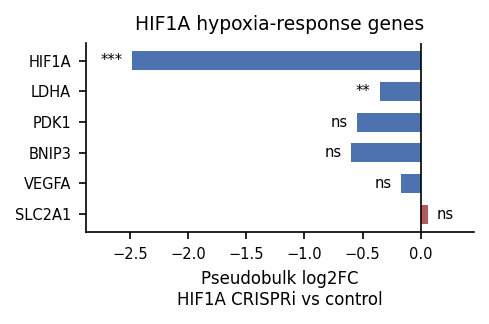

Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_log2FC_bar.png
Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_log2FC_bar.svg


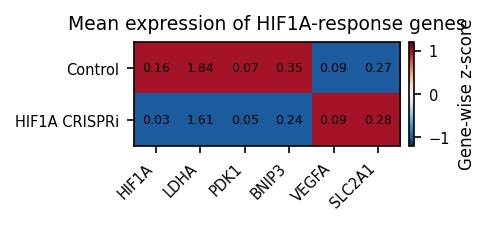

Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_mean_expression_heatmap.png
Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_mean_expression_heatmap.svg
Top down genes: ['HIF1A', 'ADCY7', 'SLC6A8', 'DHRS7B', 'LONRF2', 'ICAM1', 'MXD1', 'AC003093.1', 'PLAUR', 'SLC38A7']
Top up genes: ['SPICE1', 'PRKAR1B', 'CKAP2L', 'RBM43', 'BBS7', 'TRIM26', 'WBP1L', 'MSX1', 'TNRC6C', 'SLC27A4']


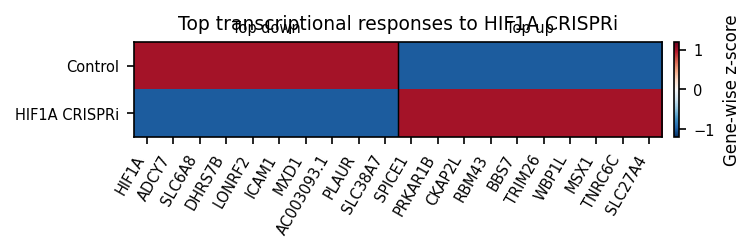

Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_top_response_genes_heatmap.png
Saved: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_top_response_genes_heatmap.svg

Plot data saved:
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_plot_data.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_top_response_heatmap_genes.csv

All figures were saved.
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_log2FC_bar.png
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_log2FC_bar.svg
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_mean_expression_heatmap.png
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF1A_focus_genes_mean_expression_heatmap.svg
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/figures/HIF

In [4]:
# ============================================================
# HIF1A human SNP case - Step 2
#
#
# /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

# ------------------------------------------------------------
# ------------------------------------------------------------
BASE_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case"
)

FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUBSET_H5AD = (
    BASE_DIR /
    "replogle_K562_HIF1A_CRISPRi_batch_matched_subset_log1p.h5ad"
)

DIFF_CSV = (
    BASE_DIR /
    "HIF1A_CRISPRi_vs_control_all_gene_response.csv"
)

FOCUS_CSV = (
    BASE_DIR /
    "HIF1A_CRISPRi_focus_hypoxia_genes.csv"
)

TOP_CSV = (
    BASE_DIR /
    "HIF1A_CRISPRi_top_up_down_genes.csv"
)

print("SUBSET_H5AD exists:", SUBSET_H5AD.exists())
print("DIFF_CSV exists:", DIFF_CSV.exists())
print("FOCUS_CSV exists:", FOCUS_CSV.exists())
print("TOP_CSV exists:", TOP_CSV.exists())


# ------------------------------------------------------------
# ------------------------------------------------------------
adata = ad.read_h5ad(SUBSET_H5AD)
diff_df = pd.read_csv(DIFF_CSV)
focus_df = pd.read_csv(FOCUS_CSV)
top_df = pd.read_csv(TOP_CSV)

print("adata:", adata.shape)
print("groups:")
display(adata.obs["analysis_group"].value_counts().rename("n_cells").to_frame())

print("focus genes:")
display(
    focus_df[
        [
            "gene",
            "pseudobulk_log2FC",
            "mean_log1p_difference",
            "MannWhitney_FDR",
            "direction",
        ]
    ]
)


# ------------------------------------------------------------
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_DOWN = "#4C72B0"
COLOR_UP = "#B55A5A"
COLOR_NEUTRAL = "#9E9E9E"


# ------------------------------------------------------------
# 3. Figure 1:
# ------------------------------------------------------------
FOCUS_ORDER = [
    "HIF1A",
    "LDHA",
    "PDK1",
    "BNIP3",
    "VEGFA",
    "SLC2A1",
]

plot_focus = (
    focus_df
    .set_index("gene")
    .loc[FOCUS_ORDER]
    .reset_index()
)

plot_focus["color"] = np.where(
    plot_focus["pseudobulk_log2FC"] < 0,
    COLOR_DOWN,
    COLOR_UP,
)

plot_focus["sig_label"] = np.where(
    plot_focus["MannWhitney_FDR"] < 0.001,
    "***",
    np.where(
        plot_focus["MannWhitney_FDR"] < 0.01,
        "**",
        np.where(
            plot_focus["MannWhitney_FDR"] < 0.05,
            "*",
            "ns",
        ),
    ),
)

fig, ax = plt.subplots(figsize=(3.3, 2.2))

y_pos = np.arange(len(plot_focus))

ax.barh(
    y_pos,
    plot_focus["pseudobulk_log2FC"],
    color=plot_focus["color"],
    edgecolor="none",
    height=0.62,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

for i, row in plot_focus.iterrows():
    x = row["pseudobulk_log2FC"]

    if x < 0:
        text_x = x - 0.08
        ha = "right"
    else:
        text_x = x + 0.08
        ha = "left"

    ax.text(
        text_x,
        i,
        row["sig_label"],
        va="center",
        ha=ha,
        fontsize=7,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_focus["gene"])
ax.invert_yaxis()

ax.set_xlabel("Pseudobulk log2FC\nHIF1A CRISPRi vs control")
ax.set_title("HIF1A hypoxia-response genes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

x_min = min(-2.8, plot_focus["pseudobulk_log2FC"].min() - 0.4)
x_max = max(0.4, plot_focus["pseudobulk_log2FC"].max() + 0.4)
ax.set_xlim(x_min, x_max)

plt.tight_layout()

fig1_png = FIG_DIR / "HIF1A_focus_genes_log2FC_bar.png"
fig1_svg = FIG_DIR / "HIF1A_focus_genes_log2FC_bar.svg"

plt.savefig(fig1_png, bbox_inches="tight")
plt.savefig(fig1_svg, bbox_inches="tight")
plt.show()

print("Saved:", fig1_png)
print("Saved:", fig1_svg)


# ------------------------------------------------------------
# 4. Figure 2:
# ------------------------------------------------------------
groups = adata.obs["analysis_group"].astype(str).to_numpy()

group_order = [
    "batch_matched_control",
    "HIF1A_CRISPRi",
]

group_labels = [
    "Control",
    "HIF1A CRISPRi",
]

gene_order = FOCUS_ORDER

gene_to_idx = {
    gene: i
    for i, gene in enumerate(adata.var_names.astype(str))
}

mean_matrix = []

for group in group_order:
    mask = groups == group

    row_values = []

    for gene in gene_order:
        idx = gene_to_idx[gene]
        row_values.append(
            float(np.mean(adata.X[mask, idx]))
        )

    mean_matrix.append(row_values)

mean_matrix = np.asarray(mean_matrix)

gene_mean = mean_matrix.mean(axis=0, keepdims=True)
gene_std = mean_matrix.std(axis=0, keepdims=True)
gene_std = np.where(gene_std == 0, 1, gene_std)

z_matrix = (mean_matrix - gene_mean) / gene_std

fig, ax = plt.subplots(figsize=(3.4, 1.55))

im = ax.imshow(
    z_matrix,
    aspect="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-1.2,
        vcenter=0,
        vmax=1.2,
    ),
)

ax.set_xticks(np.arange(len(gene_order)))
ax.set_xticklabels(gene_order, rotation=45, ha="right")

ax.set_yticks(np.arange(len(group_labels)))
ax.set_yticklabels(group_labels)

ax.set_title("Mean expression of HIF1A-response genes")

for i in range(z_matrix.shape[0]):
    for j in range(z_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{mean_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="black",
        )

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.05,
    pad=0.03,
)

cbar.set_label("Gene-wise z-score")

plt.tight_layout()

fig2_png = FIG_DIR / "HIF1A_focus_genes_mean_expression_heatmap.png"
fig2_svg = FIG_DIR / "HIF1A_focus_genes_mean_expression_heatmap.svg"

plt.savefig(fig2_png, bbox_inches="tight")
plt.savefig(fig2_svg, bbox_inches="tight")
plt.show()

print("Saved:", fig2_png)
print("Saved:", fig2_svg)


# ------------------------------------------------------------
# 5. Figure 3:
# Top response genes heatmap
#
# - Top 10 down
# - Top 10 up
# ------------------------------------------------------------
diff_for_top = diff_df.copy()

diff_for_top["max_pct_nonzero"] = diff_for_top[
    ["HIF1A_pct_nonzero", "control_pct_nonzero"]
].max(axis=1)

diff_for_top = diff_for_top.loc[
    diff_for_top["max_pct_nonzero"] >= 8
].copy()

top_down_genes = (
    diff_for_top
    .sort_values("pseudobulk_log2FC", ascending=True)
    .head(10)["gene"]
    .tolist()
)

top_up_genes = (
    diff_for_top
    .sort_values("pseudobulk_log2FC", ascending=False)
    .head(10)["gene"]
    .tolist()
)

top_genes = top_down_genes + top_up_genes

print("Top down genes:", top_down_genes)
print("Top up genes:", top_up_genes)

mean_top_matrix = []

for group in group_order:
    mask = groups == group

    row_values = []

    for gene in top_genes:
        idx = gene_to_idx[gene]
        row_values.append(
            float(np.mean(adata.X[mask, idx]))
        )

    mean_top_matrix.append(row_values)

mean_top_matrix = np.asarray(mean_top_matrix)

gene_mean = mean_top_matrix.mean(axis=0, keepdims=True)
gene_std = mean_top_matrix.std(axis=0, keepdims=True)
gene_std = np.where(gene_std == 0, 1, gene_std)

top_z_matrix = (mean_top_matrix - gene_mean) / gene_std

fig, ax = plt.subplots(figsize=(5.2, 1.8))

im = ax.imshow(
    top_z_matrix,
    aspect="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-1.2,
        vcenter=0,
        vmax=1.2,
    ),
)

ax.set_xticks(np.arange(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=60, ha="right")

ax.set_yticks(np.arange(len(group_labels)))
ax.set_yticklabels(group_labels)

ax.axvline(
    9.5,
    color="black",
    linewidth=0.7,
)

ax.text(
    4.5,
    -0.8,
    "Top down",
    ha="center",
    va="center",
    fontsize=7,
)

ax.text(
    14.5,
    -0.8,
    "Top up",
    ha="center",
    va="center",
    fontsize=7,
)

ax.set_title("Top transcriptional responses to HIF1A CRISPRi")

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.04,
    pad=0.02,
)

cbar.set_label("Gene-wise z-score")

plt.tight_layout()

fig3_png = FIG_DIR / "HIF1A_top_response_genes_heatmap.png"
fig3_svg = FIG_DIR / "HIF1A_top_response_genes_heatmap.svg"

plt.savefig(fig3_png, bbox_inches="tight")
plt.savefig(fig3_svg, bbox_inches="tight")
plt.show()

print("Saved:", fig3_png)
print("Saved:", fig3_svg)


# ------------------------------------------------------------
# ------------------------------------------------------------
plot_focus_path = FIG_DIR / "HIF1A_focus_genes_plot_data.csv"
top_gene_plot_path = FIG_DIR / "HIF1A_top_response_heatmap_genes.csv"

plot_focus.to_csv(plot_focus_path, index=False)

pd.DataFrame({
    "gene": top_genes,
    "top_group": ["top_down"] * len(top_down_genes) + ["top_up"] * len(top_up_genes),
}).to_csv(top_gene_plot_path, index=False)

print("\nPlot data saved:")
print(plot_focus_path)
print(top_gene_plot_path)


# ------------------------------------------------------------
# ------------------------------------------------------------
print("\n" + "=" * 100)
print('All figures were saved.')
print("=" * 100)

for path in [
    fig1_png,
    fig1_svg,
    fig2_png,
    fig2_svg,
    fig3_png,
    fig3_svg,
]:
    print(path)


## 5. Few-shot model dataset

Construct the model-ready AnnData object with background perturbations, a control pool, and HIF1A few-shot train, validation, and held-out test splits.

In [5]:
# ============================================================
# HIF1A human SNP case - Step 3
#
#
#
# /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/
#   replogle_K562_HIF1A_fewshot_model_dataset.h5ad
# ============================================================

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
from IPython.display import display

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# ------------------------------------------------------------
DATA_PATH = Path(
    "/root/autodl-fs/replogle_bcl11a/raw/"
    "ReplogleWeissman2022_K562_gwps.h5ad"
)

OUT_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/model_dataset"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PERT_COL = "perturbation"
BATCH_COL = "batch"
CONTROL_LABEL = "control"
TARGET_PERT = "HIF1A"

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

N_BACKGROUND_PERTS = 120

MAX_CELLS_PER_BACKGROUND_PERT = 80

MIN_CELLS_PER_BACKGROUND_PERT = 80

MAX_TOTAL_CELLS_PER_PERT_CANDIDATE = 350

CONTROL_RATIO = 3

HIF1A_TRAIN_FRAC = 0.20
HIF1A_VAL_FRAC = 0.20


# ------------------------------------------------------------
# ------------------------------------------------------------
adata = ad.read_h5ad(DATA_PATH, backed="r")

print("=" * 100)
print('Raw dataset')
print("=" * 100)
print("Path :", DATA_PATH)
print("Shape:", adata.shape)
print("X type:", type(adata.X))

obs = adata.obs.copy()

assert PERT_COL in obs.columns
assert BATCH_COL in obs.columns

pert_values = obs[PERT_COL].astype(str).to_numpy()
batch_values = obs[BATCH_COL].to_numpy()

pert_counts = obs[PERT_COL].astype(str).value_counts()

print("\nTotal perturbations:", pert_counts.shape[0])
print("Control cells:", int(pert_counts.get(CONTROL_LABEL, 0)))
print("HIF1A cells:", int(pert_counts.get(TARGET_PERT, 0)))


# ------------------------------------------------------------
# ------------------------------------------------------------
candidate_counts = pert_counts.drop(
    labels=[CONTROL_LABEL, TARGET_PERT],
    errors="ignore",
)

candidate_counts = candidate_counts.loc[
    (candidate_counts >= MIN_CELLS_PER_BACKGROUND_PERT)
    & (candidate_counts <= MAX_TOTAL_CELLS_PER_PERT_CANDIDATE)
].copy()

print("\nCandidate background perturbations:", len(candidate_counts))

if len(candidate_counts) < N_BACKGROUND_PERTS:
    print(
        'Fewer eligible background perturbations were available than requested; all eligible candidates will be used.'
    )
    selected_background_perts = candidate_counts.index.to_numpy()
else:
    selected_background_perts = rng.choice(
        candidate_counts.index.to_numpy(),
        size=N_BACKGROUND_PERTS,
        replace=False,
    )

selected_background_perts = sorted(
    [str(x) for x in selected_background_perts]
)

print("Selected background perturbations:", len(selected_background_perts))
print(selected_background_perts[:20])


# ------------------------------------------------------------
# ------------------------------------------------------------
selected_rows = []
split_map = {}
sample_kind_map = {}

background_summary_rows = []

for pert in selected_background_perts:
    rows = np.flatnonzero(pert_values == pert)

    if len(rows) == 0:
        continue

    n_take = min(
        len(rows),
        MAX_CELLS_PER_BACKGROUND_PERT,
    )

    chosen = rng.choice(
        rows,
        size=n_take,
        replace=False,
    )

    chosen = np.sort(chosen)

    # 90% train, 10% val
    shuffled = chosen.copy()
    rng.shuffle(shuffled)

    n_val = max(
        1,
        int(round(0.10 * len(shuffled))),
    )

    val_rows = set(shuffled[:n_val].tolist())
    train_rows = set(shuffled[n_val:].tolist())

    for r in train_rows:
        selected_rows.append(r)
        split_map[int(r)] = "train"
        sample_kind_map[int(r)] = "background_perturb_train"

    for r in val_rows:
        selected_rows.append(r)
        split_map[int(r)] = "val"
        sample_kind_map[int(r)] = "background_perturb_val"

    background_summary_rows.append({
        "perturbation": pert,
        "available_cells": len(rows),
        "selected_cells": n_take,
        "train_cells": len(train_rows),
        "val_cells": len(val_rows),
    })

background_summary_df = pd.DataFrame(background_summary_rows)

print("\n" + "=" * 100)
print('Background-perturbation sampling summary')
print("=" * 100)
display(background_summary_df.head())
print("Total background perturb cells:", len(selected_rows))


# ------------------------------------------------------------
# ------------------------------------------------------------
hif1a_rows = np.flatnonzero(pert_values == TARGET_PERT)

if len(hif1a_rows) == 0:
    raise ValueError('No HIF1A-perturbed cells were found.')

hif1a_rows_shuffled = hif1a_rows.copy()
rng.shuffle(hif1a_rows_shuffled)

n_hif1a_total = len(hif1a_rows_shuffled)
n_hif1a_train = max(
    20,
    int(round(n_hif1a_total * HIF1A_TRAIN_FRAC)),
)
n_hif1a_val = max(
    20,
    int(round(n_hif1a_total * HIF1A_VAL_FRAC)),
)

if n_hif1a_train + n_hif1a_val >= n_hif1a_total:
    n_hif1a_train = int(n_hif1a_total * 0.2)
    n_hif1a_val = int(n_hif1a_total * 0.2)

hif1a_train_rows = hif1a_rows_shuffled[:n_hif1a_train]
hif1a_val_rows = hif1a_rows_shuffled[
    n_hif1a_train:n_hif1a_train + n_hif1a_val
]
hif1a_test_rows = hif1a_rows_shuffled[
    n_hif1a_train + n_hif1a_val:
]

for r in hif1a_train_rows:
    selected_rows.append(int(r))
    split_map[int(r)] = "train"
    sample_kind_map[int(r)] = "HIF1A_fewshot_train"

for r in hif1a_val_rows:
    selected_rows.append(int(r))
    split_map[int(r)] = "val"
    sample_kind_map[int(r)] = "HIF1A_val"

for r in hif1a_test_rows:
    selected_rows.append(int(r))
    split_map[int(r)] = "test"
    sample_kind_map[int(r)] = "HIF1A_test"

print("\n" + "=" * 100)
print("HIF1A split")
print("=" * 100)
print("HIF1A total:", n_hif1a_total)
print("HIF1A train:", len(hif1a_train_rows))
print("HIF1A val  :", len(hif1a_val_rows))
print("HIF1A test :", len(hif1a_test_rows))


# ------------------------------------------------------------
#
# ------------------------------------------------------------
selected_pert_rows = np.asarray(
    selected_rows,
    dtype=int,
)

selected_batches = batch_values[selected_pert_rows]
control_rows_all = np.flatnonzero(pert_values == CONTROL_LABEL)

control_rows_selected = []

control_summary_rows = []

for batch_id in pd.unique(selected_batches):
    n_pert_in_batch = int(np.sum(selected_batches == batch_id))

    control_in_batch = control_rows_all[
        batch_values[control_rows_all] == batch_id
    ]

    n_select = min(
        len(control_in_batch),
        max(1, n_pert_in_batch * CONTROL_RATIO),
    )

    if n_select > 0:
        chosen_ctrl = rng.choice(
            control_in_batch,
            size=n_select,
            replace=False,
        )

        control_rows_selected.extend(chosen_ctrl.tolist())

    control_summary_rows.append({
        "batch": batch_id,
        "selected_perturb_cells": n_pert_in_batch,
        "available_control_cells": len(control_in_batch),
        "selected_control_cells": n_select,
    })

control_rows_selected = np.asarray(
    sorted(set(control_rows_selected)),
    dtype=int,
)

for r in control_rows_selected:
    selected_rows.append(int(r))
    split_map[int(r)] = "train"
    sample_kind_map[int(r)] = "control_train"

control_summary_df = pd.DataFrame(control_summary_rows)

print("\n" + "=" * 100)
print('Control-cell sampling')
print("=" * 100)
print("Selected control cells:", len(control_rows_selected))
display(control_summary_df.head())


# ------------------------------------------------------------
# ------------------------------------------------------------
selected_rows = np.asarray(
    sorted(set(selected_rows)),
    dtype=int,
)

print("\n" + "=" * 100)
print('Final selected cells')
print("=" * 100)
print("Total selected cells:", len(selected_rows))

obs_sub = obs.iloc[selected_rows].copy()

obs_sub["split"] = [
    split_map[int(r)]
    for r in selected_rows
]

obs_sub["sample_kind"] = [
    sample_kind_map[int(r)]
    for r in selected_rows
]

obs_sub["analysis_case"] = "HIF1A_human_SNP_fewshot_case"
obs_sub["heldout_perturbation"] = TARGET_PERT

obs_sub["is_control"] = (
    obs_sub[PERT_COL].astype(str) == CONTROL_LABEL
)

obs_sub["is_HIF1A"] = (
    obs_sub[PERT_COL].astype(str) == TARGET_PERT
)

obs_sub["is_background_perturb"] = (
    (~obs_sub["is_control"])
    & (~obs_sub["is_HIF1A"])
)

print("\nSplit counts:")
display(obs_sub["split"].value_counts().rename("n_cells").to_frame())

print("\nSample kind counts:")
display(obs_sub["sample_kind"].value_counts().rename("n_cells").to_frame())

print("\nPerturbation counts by split, top 20:")
display(
    obs_sub
    .groupby(["split", PERT_COL])
    .size()
    .rename("n_cells")
    .reset_index()
    .sort_values(["split", "n_cells"], ascending=[True, False])
    .head(20)
)


# ------------------------------------------------------------
#
# ------------------------------------------------------------
print("\n" + "=" * 100)
print('Expression-matrix loading')
print("=" * 100)

X_counts = adata.X[selected_rows, :]

if sparse.issparse(X_counts):
    X_counts = X_counts.toarray()
else:
    X_counts = np.asarray(X_counts)

X_counts = X_counts.astype(np.float32)

print("X_counts:", X_counts.shape, X_counts.dtype)
print("max count:", float(np.max(X_counts)))
print("zero fraction:", float(np.mean(X_counts == 0)))


# ------------------------------------------------------------
# 8. log-normalization
# ------------------------------------------------------------
if "ncounts" in obs_sub.columns:
    library_size = pd.to_numeric(
        obs_sub["ncounts"],
        errors="coerce",
    ).to_numpy(dtype=float)
    library_source = "obs['ncounts']"
elif "UMI_count" in obs_sub.columns:
    library_size = pd.to_numeric(
        obs_sub["UMI_count"],
        errors="coerce",
    ).to_numpy(dtype=float)
    library_source = "obs['UMI_count']"
else:
    library_size = X_counts.sum(axis=1).astype(float)
    library_source = "X_counts.sum(axis=1)"

library_size = np.where(
    library_size > 0,
    library_size,
    np.nan,
)

X_log1p = np.log1p(
    X_counts / library_size[:, None] * 1e4
).astype(np.float32)

print("Library source:", library_source)
print("X_log1p:", X_log1p.shape, X_log1p.dtype)


# ------------------------------------------------------------
# ------------------------------------------------------------
var_sub = adata.var.copy()

model_adata = ad.AnnData(
    X=X_log1p,
    obs=obs_sub,
    var=var_sub,
)

model_adata.layers["counts"] = sparse.csr_matrix(X_counts)

model_adata.obs["library_size_used"] = library_size

model_adata.uns["case_info"] = {
    "case_name": "HIF1A_human_SNP_fewshot_case",
    "species": "human",
    "cell_line": "K562",
    "source_dataset": "ReplogleWeissman2022_K562_gwps",
    "target_perturbation": TARGET_PERT,
    "control_label": CONTROL_LABEL,
    "normalization": "log1p(counts / library_size * 1e4)",
    "library_size_source": library_source,
    "background_perturbations": len(selected_background_perts),
    "max_cells_per_background_pert": MAX_CELLS_PER_BACKGROUND_PERT,
    "hif1a_train_cells": len(hif1a_train_rows),
    "hif1a_val_cells": len(hif1a_val_rows),
    "hif1a_test_cells": len(hif1a_test_rows),
}


# ------------------------------------------------------------
# ------------------------------------------------------------
h5ad_path = OUT_DIR / "replogle_K562_HIF1A_fewshot_model_dataset.h5ad"
obs_path = OUT_DIR / "replogle_K562_HIF1A_fewshot_model_dataset_obs.csv"
background_path = OUT_DIR / "background_perturbation_sampling_summary.csv"
control_path = OUT_DIR / "control_sampling_summary.csv"
pert_split_path = OUT_DIR / "perturbation_split_counts.csv"

model_adata.write_h5ad(h5ad_path)

obs_sub.to_csv(obs_path)

background_summary_df.to_csv(
    background_path,
    index=False,
)

control_summary_df.to_csv(
    control_path,
    index=False,
)

(
    obs_sub
    .groupby(["split", PERT_COL])
    .size()
    .rename("n_cells")
    .reset_index()
    .to_csv(pert_split_path, index=False)
)

print("\n" + "=" * 100)
print('Files saved')
print("=" * 100)
print(h5ad_path)
print(obs_path)
print(background_path)
print(control_path)
print(pert_split_path)


# ------------------------------------------------------------
# ------------------------------------------------------------
print("\n" + "=" * 100)
print('Final validation')
print("=" * 100)

print("model_adata:", model_adata.shape)

display(
    model_adata.obs["split"]
    .value_counts()
    .rename("n_cells")
    .to_frame()
)

display(
    model_adata.obs["sample_kind"]
    .value_counts()
    .rename("n_cells")
    .to_frame()
)

display(
    model_adata.obs.loc[
        model_adata.obs[PERT_COL].astype(str) == TARGET_PERT,
        ["split", "sample_kind", PERT_COL, BATCH_COL]
    ]
    .groupby(["split", "sample_kind"])
    .size()
    .rename("n_HIF1A_cells")
    .to_frame()
)

try:
    adata.file.close()
except Exception:
    pass

del adata, X_counts, X_log1p
gc.collect()

print('\nCompleted. The resulting AnnData object is ready for model training.')


Raw dataset
Path : /root/autodl-fs/replogle_bcl11a/raw/ReplogleWeissman2022_K562_gwps.h5ad
Shape: (1989578, 8248)
X type: <class 'h5py._hl.dataset.Dataset'>

Total perturbations: 9867
Control cells: 75328
HIF1A cells: 163

Candidate background perturbations: 7820
Selected background perturbations: 120
['ADAT1', 'ADPRHL2', 'AK4', 'AKR1C2', 'ASNS', 'ATP5IF1', 'ATP5PD', 'B2M', 'BAIAP2L1', 'BATF2', 'BTN3A2', 'CCDC78', 'CCT6A', 'CD69', 'CDC42SE1', 'CEBPA', 'CFL2', 'CKS2', 'CLPB', 'CLSTN1']

Background-perturbation sampling summary


,perturbation,available_cells,selected_cells,train_cells,val_cells
0,ADAT1,192,80,72,8
1,ADPRHL2,151,80,72,8
2,AK4,173,80,72,8
3,AKR1C2,208,80,72,8
4,ASNS,144,80,72,8


Total background perturb cells: 9600

HIF1A split
HIF1A total: 163
HIF1A train: 33
HIF1A val  : 33
HIF1A test : 97

Control-cell sampling
Selected control cells: 29289


,batch,selected_perturb_cells,available_control_cells,selected_control_cells
0,24,42,325,126
1,196,25,216,75
2,111,39,331,117
3,170,38,296,114
4,17,45,269,135



Final selected cells
Total selected cells: 39052

Split counts:


...


Expression-matrix loading
X_counts: (39052, 8248) float32
max count: 1639.0
zero fraction: 0.6168051951025929
Library source: obs['ncounts']
X_log1p: (39052, 8248) float32

Files saved
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/replogle_K562_HIF1A_fewshot_model_dataset.h5ad
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/replogle_K562_HIF1A_fewshot_model_dataset_obs.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/background_perturbation_sampling_summary.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/control_sampling_summary.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/perturbation_split_counts.csv

Final validation
model_adata: (39052, 8248)


,n_cells
split,
train,37962
val,993
test,97


,n_cells
sample_kind,
control_train,29289
background_perturb_train,8640
background_perturb_val,960
HIF1A_test,97
HIF1A_fewshot_train,33
HIF1A_val,33


n_HIF1A_cells
split sample_kind                            
test  HIF1A_fewshot_train                   0
      HIF1A_test                           97
      HIF1A_val                             0
      background_perturb_train              0
      background_perturb_val                0
      control_train                         0
train HIF1A_fewshot_train                  33
      HIF1A_test                            0
      HIF1A_val                             0
      background_perturb_train              0
      background_perturb_val                0
      control_train                         0
val   HIF1A_fewshot_train                   0
      HIF1A_test                            0
      HIF1A_val                            33
      background_perturb_train              0
      background_perturb_val                0
      control_train                         0


Completed. The resulting AnnData object is ready for model training.


## 6. Batch-context prediction export

Load the final batch-context BaiZe checkpoint, predict held-out HIF1A responses, and export gene-level predictions, metrics, matrices, and diagnostic figures.

H5AD exists: True /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/replogle_K562_HIF1A_fewshot_model_dataset.h5ad
batch_context_top20p True /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_runs/diffusion_HIF1A_fewshot_rna_only_batch_context/best_model_diff.pth

Model: batch_context_top20p
device: cuda
model_path: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_runs/diffusion_HIF1A_fewshot_rna_only_batch_context/best_model_diff.pth
>>> 正在加载数据: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_dataset/replogle_K562_HIF1A_fewshot_model_dataset.h5ad
>>> perturb_parse_mode=raw: 保留字符串，但自动识别 Adamson UPR 和 plus-separated 多基因扰动。
>>> component perturb gene vocab size: 122 (PAD=0, max_genes_per_condition=1)
>>> 已写入: perturb_gene_idx_matrix / is_control / nperts_clean / perturb_gene_set
>>> no-cell-line mode: using obs['batch'] as control-pool context, not as cell-line embedding.
>>> 正在计算 control context 基线表达谱.

,n_cells
HIF1A,97



Focus genes:


,gene,control_mean,true_HIF1A_mean,pred_HIF1A_mean,true_delta,pred_delta,true_direction,pred_direction,direction_match
0,HIF1A,0.160485,0.030152,0.148831,-0.130333,-0.011654,down,down,True
1,LDHA,1.837136,1.654003,1.739406,-0.183133,-0.097730,down,down,True
2,PDK1,0.072853,0.035338,0.063773,-0.037515,-0.009080,down,down,True
3,BNIP3,0.336031,0.216091,0.315471,-0.119940,-0.020560,down,down,True
4,VEGFA,0.096799,0.097464,0.090665,0.000665,-0.006134,up,down,False
5,SLC2A1,0.272806,0.288768,0.257877,0.015962,-0.014929,up,down,False



Metrics:
{
  "model_name": "batch_context_top20p",
  "model_path": "/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/model_runs/diffusion_HIF1A_fewshot_rna_only_batch_context/best_model_diff.pth",
  "n_test_cells": 97,
  "all_gene_delta_pearson": 0.017284200122977506,
  "focus_delta_pearson": 0.6991274380816841,
  "focus_direction_accuracy": 0.6666666666666666,
  "top20_true_delta_pearson": 0.4951630810621161,
  "top20_direction_accuracy": 0.65
}


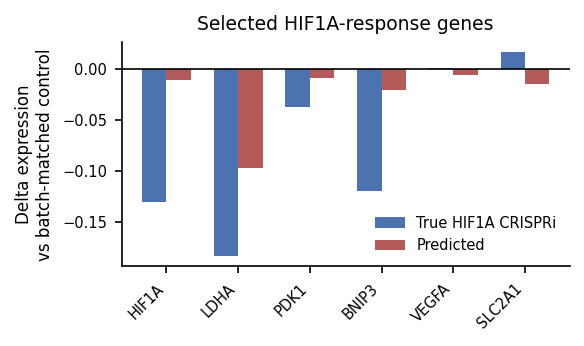

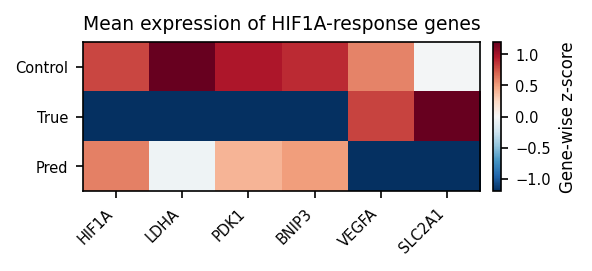


Saved files:
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_test_predictions.npz
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_test_all_gene_pred_vs_true_delta.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_focus_genes_pred_vs_true_delta.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_top20_true_delta_pred_vs_true.csv
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_prediction_gene_level_metrics.json
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/HIF1A_focus_genes_true_vs_pred_delta.png
/root/autodl-fs/replogle_bcl11a/processed/hif1a_hum

,model_name,model_path,n_test_cells,all_gene_delta_pearson,focus_delta_pearson,focus_direction_accuracy,top20_true_delta_pearson,top20_direction_accuracy
0,batch_context_top20p,/root/autodl-fs/replogle_bcl11a/processed/hif1...,97,0.017284,0.699127,0.666667,0.495163,0.65


Saved summary: /root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/HIF1A_batch_context_gene_level_comparison.csv


In [7]:
# ============================================================
# HIF1A SNP-informed case
# Batch-context model prediction export
#
#    diffusion_HIF1A_fewshot_rna_only_batch_context/best_model_top20p.pth
#    control / true / predicted
#    HIF1A, LDHA, PDK1, BNIP3, VEGFA, SLC2A1
# ============================================================

import os
import sys
import json
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# ------------------------------------------------------------
PROJECT_DIR = Path("/root/autodl-tmp/scERso")
os.chdir(PROJECT_DIR)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

os.environ["OMP_NUM_THREADS"] = "1"

import evaluate_diffusion as evalmod
from utils.data_processor import DataProcessor


# ------------------------------------------------------------
# ------------------------------------------------------------
H5AD = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/model_dataset/"
    "replogle_K562_HIF1A_fewshot_model_dataset.h5ad"
)

RUN_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/model_runs/"
    "diffusion_HIF1A_fewshot_rna_only_batch_context"
)

OUT_BASE = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/prediction_exports_batch_context"
)

OUT_BASE.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "batch_context_top20p": RUN_DIR / "best_model_diff.pth",
}

FOCUS_GENES = [
    "HIF1A",
    "LDHA",
    "PDK1",
    "BNIP3",
    "VEGFA",
    "SLC2A1",
]

print("H5AD exists:", H5AD.exists(), H5AD)
for name, path in MODEL_PATHS.items():
    print(name, path.exists(), path)


# ------------------------------------------------------------
# ------------------------------------------------------------
def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if np.std(x) <= 1e-8 or np.std(y) <= 1e-8:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def direction_label(x, eps=1e-8):
    if x > eps:
        return "up"
    if x < -eps:
        return "down"
    return "flat"


def make_eval_args(model_path, out_dir):
    "\n    Construct an argparse namespace for reusing the model-loading logic in evaluate_diffusion.py.\n    The critical settings enable batch-aware control context with background_key='batch' and control_match_scope='cell_line'.\n    "
    return argparse.Namespace(
        data_path=str(H5AD),
        model_path=str(model_path),
        out_dir=str(out_dir),

        batch_size=128,
        split_strategy="custom",
        split_col="split",
        perturb_parse_mode="raw",
        task_mode="single_gene",

        test_size=0.1,
        val_size=0.1,
        sample_steps=20,
        guidance_scale=1.0,
        target_mode="delta",

        scgpt_gene_emb_path=None,
        gene_prior_scale=None,
        use_ema=True,

        output_json=str(out_dir / "dummy.json"),
        dropout_eps=1e-3,
        de_mode="threshold",
        de_topk=200,
        de_quantile=0.9,

        atac_key=None,
        atac_bank_path=None,

        # ====================================================
        # ====================================================
        background_key="batch",
        control_match_mode="random",
        control_match_k=16,
        control_match_scope="cell_line",
        control_prototype_mode="topk_mean",
        control_prototype_temp=1.0,

        cell_line=None,
        combo_genes=None,
        weights=None,
        latent_mode="adaptive",
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
def export_one_model(model_name, model_path):
    out_dir = OUT_BASE / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    args = make_eval_args(model_path, out_dir)

    evalmod.get_args_cache = args

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("\n" + "=" * 100)
    print(f"Model: {model_name}")
    print("=" * 100)
    print("device:", device)
    print("model_path:", model_path)

    checkpoint = torch.load(
        str(model_path),
        map_location=device,
        weights_only=False,
    )

    processor = DataProcessor(
        str(H5AD),
        test_size=args.test_size,
        val_size=args.val_size,
        split_strategy=args.split_strategy,
        split_col=args.split_col,
        perturb_parse_mode=args.perturb_parse_mode,
        task_mode=args.task_mode,
        atac_key=None,
        atac_bank_path=None,
        background_key=args.background_key,
    )

    n_genes, n_perts, _ = processor.load_data()

    _, _, test_loader = processor.prepare_loaders(
        batch_size=args.batch_size,
        rna_noise=0.0,
        atac_key=None,
        atac_bank_path=None,
        background_key=args.background_key,
        control_match_mode=args.control_match_mode,
        control_match_k=args.control_match_k,
        control_match_scope=args.control_match_scope,
        control_prototype_mode=args.control_prototype_mode,
        control_prototype_temp=args.control_prototype_temp,
    )

    model = evalmod.load_model_from_checkpoint(
        checkpoint,
        n_genes,
        n_perts,
        processor,
        device,
        target_mode_override=args.target_mode,
    )

    drug_embeddings = (
        processor.drug_embeddings.to(device)
        if processor.drug_embeddings is not None
        else None
    )

    preds = []
    trues = []
    ctrls = []
    perturb_ids_all = []

    model.eval()

    print(">>> exporting predictions from test split...")

    with torch.no_grad():
        for batch in test_loader:
            ctrl = batch["rna_control"].to(device)
            target = batch["rna_target"].to(device)
            perturb = batch["perturb"].to(device)

            perturb_gene_idx = (
                batch["perturb_gene_idx"].to(device)
                if "perturb_gene_idx" in batch
                else None
            )

            is_control = (
                batch["is_control"].to(device)
                if "is_control" in batch
                else None
            )

            condition_id = (
                batch["condition_id"].to(device)
                if "condition_id" in batch
                else None
            )

            source_flag = (
                batch["source_flag"].to(device)
                if "source_flag" in batch
                else None
            )

            dose = batch["dose"].to(device) if "dose" in batch else None
            atac_feat = batch["atac_feat"].to(device) if "atac_feat" in batch else None
            drug_feat = drug_embeddings[perturb] if drug_embeddings is not None else None

            pred = model.predict_single(
                rna_control=ctrl,
                perturb=perturb,
                dose=dose,
                atac_feat=atac_feat,
                drug_feat=drug_feat,
                sample_steps=args.sample_steps,
                guidance_scale=args.guidance_scale,
                perturb_gene_idx=perturb_gene_idx,
                is_control=is_control,
                condition_id=condition_id,
                source_flag=source_flag,
            )

            preds.append(pred.detach().cpu().numpy())
            trues.append(target.detach().cpu().numpy())
            ctrls.append(ctrl.detach().cpu().numpy())
            perturb_ids_all.append(batch["perturb"].detach().cpu().numpy())

    pred = np.concatenate(preds, axis=0)
    true = np.concatenate(trues, axis=0)
    ctrl = np.concatenate(ctrls, axis=0)
    perturb_ids = np.concatenate(perturb_ids_all, axis=0)

    gene_names = np.asarray(processor.adata.var_names.astype(str))

    perturb_names = np.asarray([
        processor.id_to_perturb[int(x)]
        for x in perturb_ids
    ])

    print("pred:", pred.shape)
    print("true:", true.shape)
    print("ctrl:", ctrl.shape)
    print("test perturb counts:")
    display(pd.Series(perturb_names).value_counts().rename("n_cells").to_frame())

    # --------------------------------------------------------
    # --------------------------------------------------------
    npz_path = out_dir / "HIF1A_test_predictions.npz"

    np.savez_compressed(
        npz_path,
        pred=pred,
        true=true,
        ctrl=ctrl,
        gene_names=gene_names,
        perturb_names=perturb_names,
    )

    # --------------------------------------------------------
    # --------------------------------------------------------
    pred_mean = pred.mean(axis=0)
    true_mean = true.mean(axis=0)
    ctrl_mean = ctrl.mean(axis=0)

    pred_delta = pred_mean - ctrl_mean
    true_delta = true_mean - ctrl_mean

    all_gene_df = pd.DataFrame({
        "gene": gene_names,
        "control_mean": ctrl_mean,
        "true_HIF1A_mean": true_mean,
        "pred_HIF1A_mean": pred_mean,
        "true_delta": true_delta,
        "pred_delta": pred_delta,
        "abs_true_delta": np.abs(true_delta),
        "abs_pred_delta": np.abs(pred_delta),
    })

    all_gene_df["true_direction"] = [
        direction_label(x)
        for x in all_gene_df["true_delta"]
    ]

    all_gene_df["pred_direction"] = [
        direction_label(x)
        for x in all_gene_df["pred_delta"]
    ]

    all_gene_df["direction_match"] = (
        all_gene_df["true_direction"]
        == all_gene_df["pred_direction"]
    )

    all_gene_df = all_gene_df.sort_values(
        "abs_true_delta",
        ascending=False,
    ).reset_index(drop=True)

    all_gene_path = out_dir / "HIF1A_test_all_gene_pred_vs_true_delta.csv"
    all_gene_df.to_csv(all_gene_path, index=False)

    # --------------------------------------------------------
    # --------------------------------------------------------
    focus_df = all_gene_df.loc[
        all_gene_df["gene"].isin(FOCUS_GENES)
    ].copy()

    focus_df["gene_order"] = focus_df["gene"].map({
        gene: i
        for i, gene in enumerate(FOCUS_GENES)
    })

    focus_df = (
        focus_df
        .sort_values("gene_order")
        .drop(columns=["gene_order"])
        .reset_index(drop=True)
    )

    focus_path = out_dir / "HIF1A_focus_genes_pred_vs_true_delta.csv"
    focus_df.to_csv(focus_path, index=False)

    print("\nFocus genes:")
    display(
        focus_df[
            [
                "gene",
                "control_mean",
                "true_HIF1A_mean",
                "pred_HIF1A_mean",
                "true_delta",
                "pred_delta",
                "true_direction",
                "pred_direction",
                "direction_match",
            ]
        ]
    )

    # --------------------------------------------------------
    # Top20 true delta genes
    # --------------------------------------------------------
    top20_df = all_gene_df.head(20).copy()
    top20_path = out_dir / "HIF1A_top20_true_delta_pred_vs_true.csv"
    top20_df.to_csv(top20_path, index=False)

    # --------------------------------------------------------
    # --------------------------------------------------------
    metrics = {
        "model_name": model_name,
        "model_path": str(model_path),
        "n_test_cells": int(pred.shape[0]),

        "all_gene_delta_pearson": safe_pearson(
            pred_delta,
            true_delta,
        ),

        "focus_delta_pearson": safe_pearson(
            focus_df["pred_delta"].to_numpy(),
            focus_df["true_delta"].to_numpy(),
        ),

        "focus_direction_accuracy": float(
            np.mean(
                np.sign(focus_df["pred_delta"].to_numpy())
                == np.sign(focus_df["true_delta"].to_numpy())
            )
        ),

        "top20_true_delta_pearson": safe_pearson(
            top20_df["pred_delta"].to_numpy(),
            top20_df["true_delta"].to_numpy(),
        ),

        "top20_direction_accuracy": float(
            np.mean(
                np.sign(top20_df["pred_delta"].to_numpy())
                == np.sign(top20_df["true_delta"].to_numpy())
            )
        ),
    }

    metrics_path = out_dir / "HIF1A_prediction_gene_level_metrics.json"

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    print("\nMetrics:")
    print(json.dumps(metrics, indent=2, ensure_ascii=False))

    # --------------------------------------------------------
    # --------------------------------------------------------
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # --------------------------------------------------------
    # --------------------------------------------------------
    x = np.arange(len(focus_df))
    width = 0.34

    fig, ax = plt.subplots(figsize=(4.0, 2.35))

    ax.bar(
        x - width / 2,
        focus_df["true_delta"],
        width=width,
        label="True HIF1A CRISPRi",
        color="#4C72B0",
        edgecolor="none",
    )

    ax.bar(
        x + width / 2,
        focus_df["pred_delta"],
        width=width,
        label="Predicted",
        color="#B55A5A",
        edgecolor="none",
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        focus_df["gene"],
        rotation=45,
        ha="right",
    )

    ax.set_ylabel("Delta expression\nvs batch-matched control")
    ax.set_title("Selected HIF1A-response genes")
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    fig1_png = out_dir / "HIF1A_focus_genes_true_vs_pred_delta.png"
    fig1_svg = out_dir / "HIF1A_focus_genes_true_vs_pred_delta.svg"

    plt.savefig(fig1_png, bbox_inches="tight")
    plt.savefig(fig1_svg, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Figure 2: Control / True / Pred heatmap
    # --------------------------------------------------------
    matrix = np.vstack([
        focus_df["control_mean"].to_numpy(),
        focus_df["true_HIF1A_mean"].to_numpy(),
        focus_df["pred_HIF1A_mean"].to_numpy(),
    ])

    z = (matrix - matrix.mean(axis=0, keepdims=True)) / (
        matrix.std(axis=0, keepdims=True) + 1e-8
    )

    fig, ax = plt.subplots(figsize=(4.0, 1.85))

    im = ax.imshow(
        z,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-1.2,
        vmax=1.2,
    )

    ax.set_xticks(np.arange(len(focus_df)))
    ax.set_xticklabels(
        focus_df["gene"],
        rotation=45,
        ha="right",
    )

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Control", "True", "Pred"])

    ax.set_title("Mean expression of HIF1A-response genes")

    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.05,
        pad=0.03,
    )
    cbar.set_label("Gene-wise z-score")

    plt.tight_layout()

    fig2_png = out_dir / "HIF1A_focus_genes_control_true_pred_heatmap.png"
    fig2_svg = out_dir / "HIF1A_focus_genes_control_true_pred_heatmap.svg"

    plt.savefig(fig2_png, bbox_inches="tight")
    plt.savefig(fig2_svg, bbox_inches="tight")
    plt.show()

    print("\nSaved files:")
    print(npz_path)
    print(all_gene_path)
    print(focus_path)
    print(top20_path)
    print(metrics_path)
    print(fig1_png)
    print(fig1_svg)
    print(fig2_png)
    print(fig2_svg)

    try:
        processor.adata.file.close()
    except Exception:
        pass

    return {
        "model_name": model_name,
        "metrics": metrics,
        "focus_df": focus_df,
        "top20_df": top20_df,
        "all_gene_df": all_gene_df,
    }


# ------------------------------------------------------------
# ------------------------------------------------------------
results = {}

for model_name, model_path in MODEL_PATHS.items():
    results[model_name] = export_one_model(
        model_name=model_name,
        model_path=model_path,
    )


# ------------------------------------------------------------
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    res["metrics"]
    for res in results.values()
])

print("\n" + "=" * 100)
print("Batch-context model comparison")
print("=" * 100)

display(summary_df)

summary_path = OUT_BASE / "HIF1A_batch_context_gene_level_comparison.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved summary:", summary_path)


## 7. Core HIF1A-axis response figure

Generate the compact manuscript figure comparing observed and predicted response deltas for the core HIF1A-axis genes.

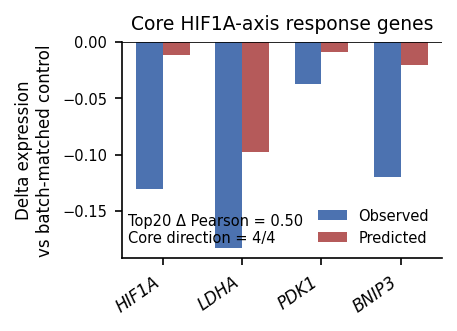

Saved:
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/paper_figures/HIF1A_core_axis_true_vs_pred_delta_batch_context.png
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/paper_figures/HIF1A_core_axis_true_vs_pred_delta_batch_context.svg


In [8]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Final paper-style plot for batch-context HIF1A prediction
# ============================================================

BASE_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/prediction_exports_batch_context/"
    "batch_context_top20p"
)

FOCUS_CSV = BASE_DIR / "HIF1A_focus_genes_pred_vs_true_delta.csv"
METRIC_JSON = BASE_DIR / "HIF1A_prediction_gene_level_metrics.json"

OUT_DIR = BASE_DIR / "paper_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FOCUS_CSV)

with open(METRIC_JSON, "r", encoding="utf-8") as f:
    metrics = json.load(f)

core_genes = ["HIF1A", "LDHA", "PDK1", "BNIP3"]

plot_df = (
    df.set_index("gene")
    .loc[core_genes]
    .reset_index()
)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_TRUE = "#4C72B0"
COLOR_PRED = "#B55A5A"

x = np.arange(len(plot_df))
width = 0.34

fig, ax = plt.subplots(figsize=(3.15, 2.25))

ax.bar(
    x - width / 2,
    plot_df["true_delta"],
    width=width,
    color=COLOR_TRUE,
    edgecolor="none",
    label="Observed",
)

ax.bar(
    x + width / 2,
    plot_df["pred_delta"],
    width=width,
    color=COLOR_PRED,
    edgecolor="none",
    label="Predicted",
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["gene"], rotation=35, ha="right", fontstyle="italic")

ax.set_ylabel("Delta expression\nvs batch-matched control")
ax.set_title("Core HIF1A-axis response genes")

ax.legend(frameon=False, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

metric_text = (
    f"Top20 Δ Pearson = {metrics['top20_true_delta_pearson']:.2f}\n"
    f"Core direction = 4/4"
)

ax.text(
    0.02,
    0.06,
    metric_text,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=7,
)

plt.tight_layout()

png_path = OUT_DIR / "HIF1A_core_axis_true_vs_pred_delta_batch_context.png"
svg_path = OUT_DIR / "HIF1A_core_axis_true_vs_pred_delta_batch_context.svg"

plt.savefig(png_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(svg_path)


## 8. Held-out response-gene figure

Generate the final broad held-out response-gene visualization using the manuscript color palette and the batch-context prediction export.

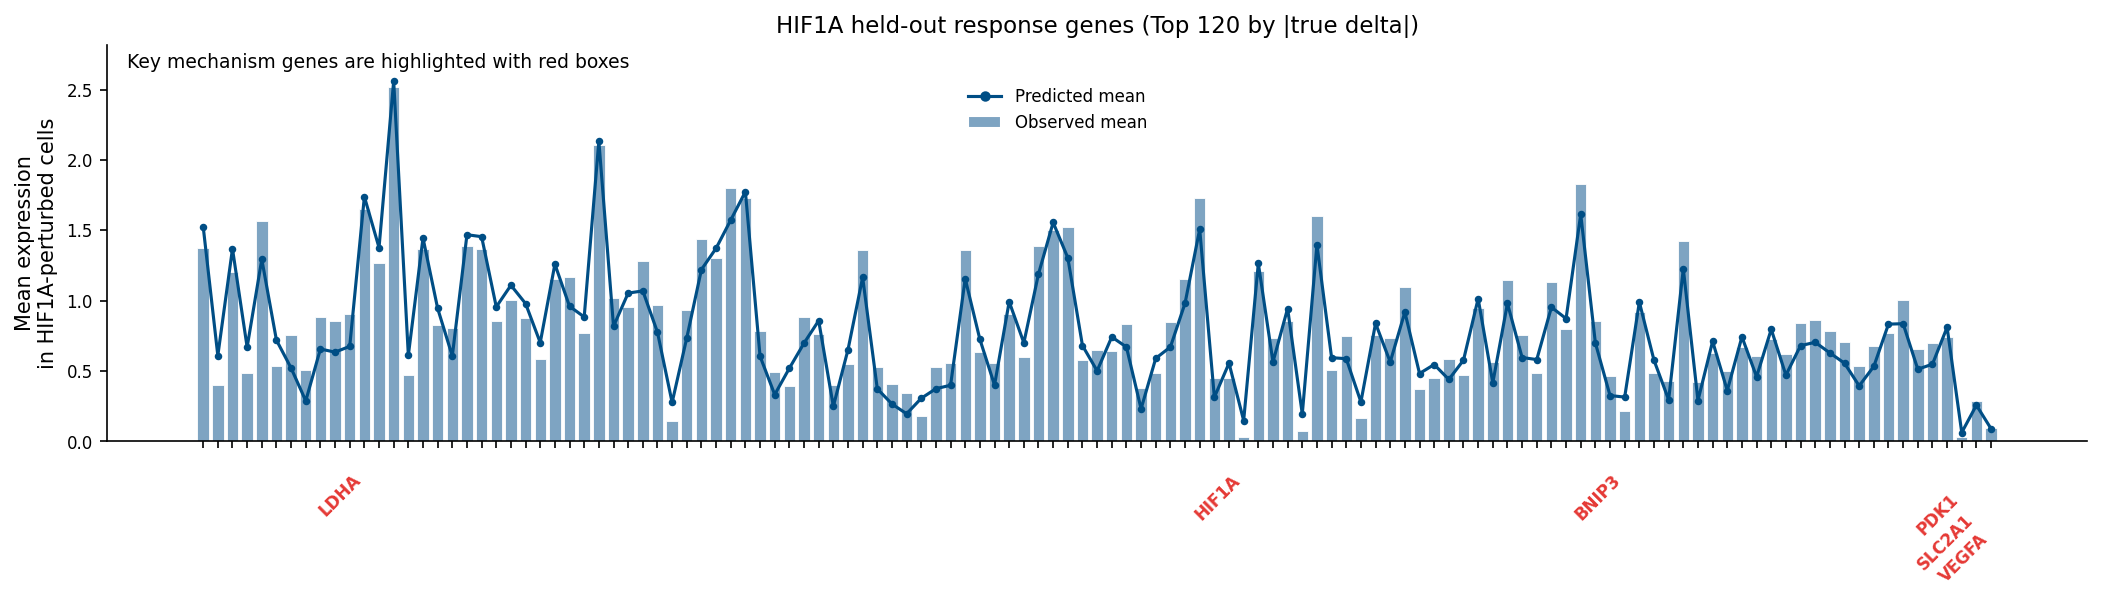

Saved:
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/paper_figures/HIF1A_top120_heldout_response_genes_mean_no_redbox_for_manual_edit.png
/root/autodl-fs/replogle_bcl11a/processed/hif1a_human_snp_case/prediction_exports_batch_context/batch_context_top20p/paper_figures/HIF1A_top120_heldout_response_genes_mean_no_redbox_for_manual_edit.svg


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# ============================================================
BASE_DIR = Path(
    "/root/autodl-fs/replogle_bcl11a/processed/"
    "hif1a_human_snp_case/prediction_exports_batch_context/"
    "batch_context_top20p"
)

ALL_GENE_CSV = BASE_DIR / "HIF1A_test_all_gene_pred_vs_true_delta.csv"

OUT_DIR = BASE_DIR / "paper_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# ============================================================
df = pd.read_csv(ALL_GENE_CSV)

required_cols = ["gene", "abs_true_delta", "true_HIF1A_mean", "pred_HIF1A_mean"]

for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")


# ============================================================
# ============================================================
highlight_genes = ["HIF1A", "LDHA", "PDK1", "BNIP3", "VEGFA", "SLC2A1"]


# ============================================================
# ============================================================
TOP_N = 120

df = df.copy()

top_df = df.sort_values("abs_true_delta", ascending=False).head(TOP_N).copy()
extra_df = df[df["gene"].isin(highlight_genes)].copy()

plot_df = (
    pd.concat([top_df, extra_df], axis=0)
    .drop_duplicates(subset=["gene"])
    .copy()
)

plot_df = plot_df.sort_values("abs_true_delta", ascending=False).reset_index(drop=True)
plot_df["is_highlight"] = plot_df["gene"].isin(highlight_genes)


# ============================================================
# ============================================================
COLOR_PAIRS = {
    "Baize RNA": {
        "dark": "#DF8932",
        "light": "#E6C08C",
    },
    "Baize ATAC": {
        "dark": "#8F1F22",
        "light": "#BF888E",
    },
    "No Diffusion": {
        "dark": "#004E85",
        "light": "#7EA4C2",
    },
}

PAIR_NAME = "No Diffusion"
PAIR = COLOR_PAIRS[PAIR_NAME]

PRED_COLOR = PAIR["dark"]
OBS_COLOR = PAIR["light"]

HIGHLIGHT_BOX_COLOR = "#E53935"


# ============================================================
# ============================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# ============================================================
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14.5, 4.4))


ax.bar(
    x,
    plot_df["true_HIF1A_mean"].values,
    width=0.78,
    color=OBS_COLOR,
    edgecolor="white",
    linewidth=0.4,
    zorder=2,
    label="Observed mean",
)


ax.plot(
    x,
    plot_df["pred_HIF1A_mean"].values,
    color=PRED_COLOR,
    linewidth=1.5,
    marker="o",
    markersize=2.6,
    zorder=3,
    label="Predicted mean",
)


# ============================================================
# ============================================================
ymin = min(
    plot_df["true_HIF1A_mean"].min(),
    plot_df["pred_HIF1A_mean"].min()
)

ymax = max(
    plot_df["true_HIF1A_mean"].max(),
    plot_df["pred_HIF1A_mean"].max()
)

ypad = 0.10 * (ymax - ymin + 1e-8)

if ymin > 0:
    ymin_plot = 0
else:
    ymin_plot = ymin - ypad

ax.set_ylim(ymin_plot, ymax + ypad)


# ============================================================
# ============================================================
ax.set_xticks(x)
ax.set_xticklabels([""] * len(plot_df))


label_y_offsets = {
    "LDHA": -0.075,
    "HIF1A": -0.075,
    "BNIP3": -0.075,
    "PDK1": -0.125,
    "SLC2A1": -0.175,
    "VEGFA": -0.225,
}

for i, row in plot_df.iterrows():
    gene = row["gene"]

    if gene not in highlight_genes:
        continue

    y_offset = label_y_offsets.get(gene, -0.075)

    ax.text(
        i,
        y_offset,
        gene,
        transform=ax.get_xaxis_transform(),
        rotation=45,
        ha="right",
        va="top",
        fontsize=8,
        color=HIGHLIGHT_BOX_COLOR,
        fontweight="bold",
        clip_on=False,
    )


# ============================================================
# ============================================================
ax.set_title(f"HIF1A held-out response genes (Top {TOP_N} by |true delta|)")

ax.set_ylabel("Mean expression\nin HIF1A-perturbed cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.01,
    0.98,
    "Key mechanism genes are highlighted with red boxes",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)


# ============================================================
# ============================================================
legend_handles = [
    Line2D(
        [0], [0],
        color=PRED_COLOR,
        marker="o",
        markersize=4,
        linewidth=1.5,
        label="Predicted mean",
    ),
    Patch(
        facecolor=OBS_COLOR,
        edgecolor="white",
        label="Observed mean",
    ),
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.48, 0.91),
    borderaxespad=0.0,
)


plt.subplots_adjust(left=0.07, right=0.98, top=0.90, bottom=0.30)


# ============================================================
# ============================================================
png_path = OUT_DIR / f"HIF1A_top{TOP_N}_heldout_response_genes_mean_no_redbox_for_manual_edit.png"
svg_path = OUT_DIR / f"HIF1A_top{TOP_N}_heldout_response_genes_mean_no_redbox_for_manual_edit.svg"

plt.savefig(png_path, bbox_inches="tight")
plt.savefig(svg_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(svg_path)
